# | Updating Models based on input data to achieve better accuracy

For models trained on David Bowie, we have train 17 predict 15 and train 15 predict 17 and thus we have corrected predictions...



### working on trial 17

In [ ]:
# using logic from postanalysis_review.py we will pull select frames from the labeled data to retrain our algorithms
# Three types of logics to implement:
# 1. Pull frames from data in random fashion
# 2. Pull frames from data to maximize displacement capture
# 3. Pull frames from data using DINO embedding to maximize embedding space coverage


In [1]:
# pull data from each of the 3 logics and save as new csv files to be used for retraining the algorithms
# pull from:
# img stack - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT17\DavidBowie_n400_T15_snapshot150
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT17\DavidBowie_n400_T15_snapshot125
# Updated - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv

# img stack - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15
# Pred 1 - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n400_T17_snapshot125
# Pred 2 - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n400_T17_snapshot150
# Updated - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv


In [ ]:
# Frame Selection Logic 1: Random Sampling
# - Randomly select a specified number of frames from the dataset.
# Frame Selection Logic 2: Maximize Displacement Capture
# - Select frames that capture the maximum displacement of key points across the dataset.
# Frame Selection Logic 3: DINO Embedding Space Coverage
# - Use DINO embeddings to select frames that maximize coverage of the embedding space, ensuring a
# diverse set of frames for retraining the algorithms.


# Sampling Helper Functions

In [75]:
# random sampling logic
import os
import random
import pandas as pd
import xrommtools_copy
from os import mkdir
import re
from pathlib import Path

# randomly select frames from the dataset
def random_frame_selection(
    dataframe,
    image_folder_path,
    num_frames=50,
    camera_subdir="Cam1_Img00UND_Trial15",
    image_prefix="Cam1_Img00_UND",
    seed=42,
):
    total_frames = len(dataframe)
    if num_frames > total_frames:
        raise ValueError(f"num_frames ({num_frames}) cannot be greater than total frames ({total_frames})")
    if num_frames <= 0:
        raise ValueError("num_frames must be > 0")

    rng = random.Random(seed)
    selected_indices = sorted(rng.sample(range(total_frames), int(num_frames)))
    trimmed = dataframe.iloc[selected_indices].copy()

    def _resolve_image_path(idx):
        base = os.path.join(image_folder_path, camera_subdir, f"{image_prefix}.{idx + 1:04d}")
        for ext in (".jpg", ".jpeg", ".tiff", ".tif", ".png"):
            p = base + ext
            if os.path.isfile(p):
                return p
        return None

    trimmed["image_path"] = [_resolve_image_path(i) for i in selected_indices]

    meta = {
        int(i): {
            "label": "Random sample",
        }
        for i in selected_indices
    }

    summary_lines = [
        f"Random {len(selected_indices)} frames",
        f"Source {camera_subdir}",
    ]

    return trimmed, meta, summary_lines

from PIL import Image


def _build_zone_specs(frame_limit, zone_size=400):
    """Create contiguous frame zones used for weighted sampling.

    Parameters
    ----------
    frame_limit : int
        Total number of frames available in the dataframe.
    zone_size : int, default=400
        Number of frames per zone.

    Returns
    -------
    list[dict]
        Zone descriptors with keys: zone_index, start, end, and label.
    """
    starts = list(range(0, frame_limit, zone_size))
    zones = []
    for idx, start in enumerate(starts):
        end = min(start + zone_size, frame_limit)
        zones.append(
            {
                "zone_index": idx,
                "start": int(start),
                "end": int(end),
                "label": f"Z{idx + 1} {start + 1}-{end}",
            }
        )
    return zones


def _allocate_counts(weights, total_count):
    """Distribute an integer frame budget across zones from nonnegative weights.

    Uses floor allocation plus remainder assignment by largest fractional part.
    If all weights are invalid or zero, allocation defaults to uniform.

    Parameters
    ----------
    weights : sequence[float]
        Relative zone importance values.
    total_count : int
        Total number of frames to allocate.

    Returns
    -------
    list[int]
        Integer allocations per weight entry, summing to total_count when possible.
    """
    if total_count <= 0 or len(weights) == 0:
        return [0 for _ in weights]

    w = np.asarray(weights, dtype=float)
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
    if float(np.sum(w)) <= 0:
        w = np.ones(len(weights), dtype=float)
    w = w / float(np.sum(w))

    raw = w * int(total_count)
    counts = np.floor(raw).astype(int)
    remaining = int(total_count - np.sum(counts))
    if remaining > 0:
        remainders = raw - counts
        for i in np.argsort(-remainders)[:remaining]:
            counts[int(i)] += 1
    return counts.tolist()


def _zone_for_frame(frame_idx, zones):
    """Return the zone dictionary containing a given frame index.

    Parameters
    ----------
    frame_idx : int
        Frame index to locate.
    zones : list[dict]
        Zone list from _build_zone_specs.

    Returns
    -------
    dict | None
        Matching zone, last zone fallback if out of range, or None when zones is empty.
    """
    for zone in zones:
        if zone["start"] <= frame_idx < zone["end"]:
            return zone
    return zones[-1] if zones else None


def _cam_xy_columns(dataframe, cam="cam1"):
    """Find paired X/Y coordinate columns for one camera.

    Column names are expected to end with '<camera>_X' and '<camera>_Y',
    for example: 'MarkerA_cam1_X', 'MarkerA_cam1_Y'.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input points table.
    cam : str, default='cam1'
        Camera token in column suffixes ('cam1', 'cam2', etc.).

    Returns
    -------
    list[tuple[str, str]]
        Sorted (x_col, y_col) pairs where both coordinates exist.
    """
    pat_x = re.compile(rf".+_{cam}_X$")
    pat_y = re.compile(rf".+_{cam}_Y$")
    x_cols = sorted([c for c in dataframe.columns if pat_x.match(str(c))])
    y_cols = sorted([c for c in dataframe.columns if pat_y.match(str(c))])

    x_map = {c.rsplit(f"_{cam}_", 1)[0]: c for c in x_cols}
    y_map = {c.rsplit(f"_{cam}_", 1)[0]: c for c in y_cols}
    keys = sorted(set(x_map).intersection(y_map))
    return [(x_map[k], y_map[k]) for k in keys]


def _frame_displacement_from_df(dataframe, xy_pairs, start_frame, end_frame):
    """Compute mean marker displacement between two frames.

    Displacement is Euclidean distance per marker pair, then averaged across
    markers with finite values at both frames.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Coordinate table.
    xy_pairs : list[tuple[str, str]]
        (x_col, y_col) pairs for one camera.
    start_frame : int
        Start frame index.
    end_frame : int
        End frame index.

    Returns
    -------
    float | None
        Mean displacement in pixels, or None if not computable.
    """
    if not xy_pairs or start_frame == end_frame:
        return None

    s = dataframe.iloc[int(start_frame)]
    e = dataframe.iloc[int(end_frame)]
    distances = []
    for x_col, y_col in xy_pairs:
        x0 = pd.to_numeric(s[x_col], errors="coerce")
        y0 = pd.to_numeric(s[y_col], errors="coerce")
        x1 = pd.to_numeric(e[x_col], errors="coerce")
        y1 = pd.to_numeric(e[y_col], errors="coerce")
        if np.isfinite(x0) and np.isfinite(y0) and np.isfinite(x1) and np.isfinite(y1):
            distances.append(float(np.hypot(x1 - x0, y1 - y0)))

    if len(distances) == 0:
        return None
    return float(np.mean(distances))


def _load_dino_components(model_name="dinov2_vits14"):
    """Load DINOv2 model + image transform (mirrors PostAnalysis_review logic)."""
    try:
        import torch
        from torchvision import transforms
    except Exception as exc:
        raise RuntimeError(
            "DINO selection requires torch and torchvision in the active environment."
        ) from exc

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )
    return {
        "torch": torch,
        "model": model,
        "transform": transform,
        "device": device,
    }


def _compute_dino_embeddings(image_paths, model_name="dinov2_vits14", batch_size=16):
    """Compute normalized DINO embeddings for a list of image paths."""
    if not image_paths:
        return np.empty((0, 0), dtype=np.float32)

    components = _load_dino_components(model_name=model_name)
    torch = components["torch"]
    model = components["model"]
    transform = components["transform"]
    device = components["device"]

    chunks = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start:start + int(batch_size)]
        tensors = []
        for p in batch_paths:
            with Image.open(p) as img:
                tensors.append(transform(img.convert("RGB")))
        if not tensors:
            continue

        batch = torch.stack(tensors).to(device)
        with torch.no_grad():
            feats = model(batch)

        if isinstance(feats, dict):
            if "x_norm_clstoken" in feats:
                feats = feats["x_norm_clstoken"]
            else:
                feats = next(iter(feats.values()))
        elif isinstance(feats, (tuple, list)):
            feats = feats[0]

        chunks.append(feats.detach().cpu().numpy())

    if not chunks:
        return np.empty((0, 0), dtype=np.float32)

    emb = np.concatenate(chunks, axis=0).astype(np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    return emb / norms


def _k_center_greedy(embeddings, k, seed=42):
    """Select k diverse items using farthest-first traversal in cosine space."""
    n = int(embeddings.shape[0])
    if n <= 0 or k <= 0:
        return [], {}
    if k >= n:
        return list(range(n)), {int(i): 0.0 for i in range(n)}

    rng = np.random.default_rng(seed)
    first = int(rng.integers(0, n))
    selected = [first]
    diversity_gain = {int(first): 0.0}

    sim = embeddings @ embeddings[first].reshape(-1, 1)
    min_dist = 1.0 - np.squeeze(sim, axis=1)
    min_dist[first] = -np.inf

    for _ in range(k - 1):
        idx = int(np.argmax(min_dist))
        gain = float(min_dist[idx]) if np.isfinite(min_dist[idx]) else 0.0
        selected.append(idx)
        diversity_gain[int(idx)] = max(gain, 0.0)

        dist_to_new = 1.0 - np.squeeze(embeddings @ embeddings[idx].reshape(-1, 1), axis=1)
        min_dist = np.minimum(min_dist, dist_to_new)
        min_dist[selected] = -np.inf

    return selected, diversity_gain


def displacement_frame_selection(
    dataframe,
    image_folder_path,
    num_frames=20,
    zone_size=400,
    camera="cam1",
    camera_subdir="Cam1_Img00UND_Trial15",
    image_prefix="Cam1_Img00_UND",
    seed=42,
 ):
    """Select frames by displacement-weighted zone sampling.

    Workflow
    --------
    1. Split timeline into fixed-size zones.
    2. Score each zone using average marker displacement from zone start to end.
    3. Allocate frame counts per zone proportional to displacement.
    4. Randomly sample within each zone (seeded), then backfill if needed.
    5. Return selected rows with image_path, per-frame metadata, and summary text.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input dataframe containing '<marker>_<camera>_X/Y' columns.
    image_folder_path : str or Path
        Root folder that contains camera image subdirectories.
    num_frames : int, default=20
        Number of frames to select.
    zone_size : int, default=400
        Zone size in frames for displacement scoring.
    camera : str, default='cam1'
        Camera suffix to use when finding coordinate columns.
    camera_subdir : str, default='Cam1_Img00UND_Trial15'
        Subfolder used to construct output image paths.
    image_prefix : str, default='Cam1_Img00_UND'
        Image filename prefix before '.####.jpg'.
    seed : int, default=42
        Random seed for reproducible sampling.

    Returns
    -------
    tuple[pandas.DataFrame, dict, list[str]]
        trimmed : Selected dataframe rows with added 'image_path'.
        meta : Mapping frame_index -> {'label', 'zone_weight', 'avg_displacement'}.
        summary_lines : Human-readable selection summary per zone.

    Raises
    ------
    ValueError
        If no X/Y columns are found for the requested camera.
    """
    frame_limit = len(dataframe)
    count = min(int(num_frames), int(frame_limit))
    zones = _build_zone_specs(frame_limit, zone_size=zone_size)
    if count <= 0 or not zones:
        return [], {}, ["Disp", "No frames"]

    xy_pairs = _cam_xy_columns(dataframe, cam=camera)
    if not xy_pairs:
        raise ValueError(f"No {camera} X/Y columns found in dataframe")

    zone_scores = []
    for zone in zones:
        end_frame = min(zone["start"] + zone_size, frame_limit - 1)
        disp = _frame_displacement_from_df(dataframe, xy_pairs, zone["start"], end_frame)
        zone_scores.append(float(disp) if disp is not None and np.isfinite(disp) else 0.0)

    zone_counts = _allocate_counts(zone_scores, count)
    total_score = float(np.sum(zone_scores))
    if total_score > 0:
        zone_weights = [float(s) / total_score for s in zone_scores]
    else:
        zone_weights = [1.0 / len(zones) for _ in zones]

    rng = np.random.default_rng(seed)
    selected = []
    meta = {}

    for zone, alloc_count, zone_weight, zone_score in zip(zones, zone_counts, zone_weights, zone_scores):
        zone_frames = np.arange(zone["start"], zone["end"], dtype=int)
        if alloc_count <= 0 or zone_frames.size == 0:
            continue
        pick_count = min(int(alloc_count), int(zone_frames.size))
        picks = np.sort(rng.choice(zone_frames, size=pick_count, replace=False))
        for frame in picks.tolist():
            selected.append(int(frame))
            meta[int(frame)] = {
                "label": str(zone["label"]),
                "zone_weight": float(zone_weight),
                "avg_displacement": float(zone_score),
            }

    if len(selected) < count:
        remaining = np.setdiff1d(np.arange(frame_limit, dtype=int), np.asarray(selected, dtype=int), assume_unique=False)
        fill_count = min(int(count - len(selected)), int(remaining.size))
        if fill_count > 0:
            fill = np.sort(rng.choice(remaining, size=fill_count, replace=False))
            for frame in fill.tolist():
                zone = _zone_for_frame(int(frame), zones)
                selected.append(int(frame))
                meta[int(frame)] = {
                    "label": str(zone["label"]) if zone else "Fallback",
                    "zone_weight": float(zone_weights[int(zone["zone_index"])]) if zone else 0.0,
                    "avg_displacement": float(zone_scores[int(zone["zone_index"])]) if zone else 0.0,
                }

    selected = sorted(set(int(f) for f in selected))[:count]

    trimmed = dataframe.iloc[selected].copy()
    def _resolve_image_path(image_folder_path, camera_subdir, image_prefix, idx):
        base = os.path.join(image_folder_path, camera_subdir, f"{image_prefix}.{idx + 1:04d}")
        for ext in (".jpg", ".jpeg", ".tiff", ".tif", ".png"):
            p = base + ext
            if os.path.isfile(p):
                return p
        return None

    trimmed["image_path"] = [
        _resolve_image_path(image_folder_path, camera_subdir, image_prefix, idx)
        for idx in selected
    ]

    summary_lines = [f"Disp {len(selected)} frames"]
    for zone, zone_weight, zone_count in zip(zones, zone_weights, zone_counts):
        if zone_count > 0:
            summary_lines.append(f"Z{zone['zone_index'] + 1} {zone_weight:.2f} ({zone_count})")

    return trimmed, meta, summary_lines


def dino_diversity_frame_selection(
    dataframe,
    image_folder_path,
    num_frames=20,
    camera="cam1",
    camera_subdir="Cam1_Img00UND_Trial15",
    image_prefix="Cam1_Img00_UND",
    seed=42,
    model_name="dinov2_vits14",
    batch_size=16,
):
    """Select diverse frames using DINO embeddings + k-center greedy sampling."""
    frame_limit = len(dataframe)
    count = min(int(num_frames), int(frame_limit))

    # Always return DataFrame (never list) so caller can safely to_csv.
    def _empty_result(msg):
        empty = dataframe.iloc[[]].copy()
        empty["image_path"] = []
        return empty, {}, ["DINO", msg]

    if count <= 0:
        return _empty_result("No frames")

    # Resolve actual files with extension fallback.
    def _resolve_image_path(idx):
        base = os.path.join(image_folder_path, camera_subdir, f"{image_prefix}.{idx + 1:04d}")
        for ext in (".jpg", ".jpeg", ".tiff", ".tif", ".png"):
            p = base + ext
            if os.path.isfile(p):
                return p
        return None

    resolved_paths = [_resolve_image_path(i) for i in range(frame_limit)]
    available_idx = [i for i, p in enumerate(resolved_paths) if p is not None]

    if not available_idx:
        return _empty_result("No image files found")

    available_paths = [resolved_paths[i] for i in available_idx]
    use_count = min(count, len(available_paths))

    embeddings = _compute_dino_embeddings(
        available_paths,
        model_name=model_name,
        batch_size=batch_size,
    )
    if embeddings.size == 0:
        return _empty_result(f"No embeddings for {camera}")

    selected_local, diversity_gain = _k_center_greedy(
        embeddings,
        use_count,
        seed=seed,
    )

    selected = sorted(int(available_idx[i]) for i in selected_local)

    trimmed = dataframe.iloc[selected].copy()
    trimmed["image_path"] = [resolved_paths[idx] for idx in selected]

    meta = {}
    for local_idx in selected_local:
        frame = int(available_idx[local_idx])
        meta[frame] = {
            "label": f"DINO {camera}",
            "source_camera": str(camera),
            "diversity_gain": float(diversity_gain.get(int(local_idx), 0.0)),
        }

    gains = [float(v) for v in diversity_gain.values()]
    mean_gain = float(np.mean(gains)) if gains else 0.0
    summary_lines = [
        f"DINO {len(selected)} frames",
        f"Source {camera}",
        f"Mean gain {mean_gain:.4f}",
    ]

    return trimmed, meta, summary_lines



In [ ]:


# Hard Coded logic to build predicted csv paths based on bird, nframes, trial, snapshot, and root

def build_predicted_csv_paths(
    bird: str,
    nframes: int,
    trial: int,
    snapshot: int,
    root: str = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut",
    ) -> tuple[str, str]:

    bird = str(bird)
    nframes = int(nframes)
    trial = int(trial)
    snapshot = int(snapshot)
    if trial not in (15, 17):
        raise ValueError("trial must be 15 or 17")

    # Train/eval pairing used in your folders
    train_trial = 15 if trial == 17 else 17
    eval_trial = trial

    # Bird-specific naming pieces (extend as needed)
    cam_prefix_by_bird = {
        "DavidBowie": "db",
    }
    dlc_tag_by_bird_evaltrial = {
        ("DavidBowie", 17): "CanariApr24",
        ("DavidBowie", 15): "CanariApr22",
    }

    if bird not in cam_prefix_by_bird:
        raise ValueError(f"Unsupported bird: {bird}")

    key = (bird, eval_trial)
    if key not in dlc_tag_by_bird_evaltrial:
        raise ValueError(f"Missing DLC tag mapping for {key}")

    cam_prefix = cam_prefix_by_bird[bird]
    dlc_tag = dlc_tag_by_bird_evaltrial[key]

    base = (
        Path(root)
        / bird
        / "ExperimentEval"
        / "UFBatch"
        / f"TrainT{train_trial}_EvalT{eval_trial}"
        / f"{bird}_n{nframes}_T{train_trial}_snapshot{snapshot}"
    )

    cam1 = base / f"{cam_prefix}_cam1_T{eval_trial}DLC_Resnet50_{dlc_tag}shuffle1_snapshot_{snapshot}.csv"
    cam2 = base / f"{cam_prefix}_cam2_T{eval_trial}DLC_Resnet50_{dlc_tag}shuffle1_snapshot_{snapshot}.csv"
    return str(cam1), str(cam2)

In [53]:
DB_n400_T17_snapshot125_paths = build_predicted_csv_paths("DavidBowie", 400, 17, 125)
print(DB_n400_T17_snapshot125_paths)



('C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\ExperimentEval\\UFBatch\\TrainT15_EvalT17\\DavidBowie_n400_T15_snapshot125\\db_cam1_T17DLC_Resnet50_Canari*shuffle1_snapshot_125.csv', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\ExperimentEval\\UFBatch\\TrainT15_EvalT17\\DavidBowie_n400_T15_snapshot125\\db_cam2_T17DLC_Resnet50_Canari*shuffle1_snapshot_125.csv')


## Loading in Data

In [54]:
# predicted csv files
DB_n400_EvalT17_snapshot125_paths = build_predicted_csv_paths("DavidBowie", 400, 17, 125)
DB_n400_EvalT17_snapshot150_paths = build_predicted_csv_paths("DavidBowie", 400, 17, 150)
DB_n400_EvalT15_snapshot125_paths = build_predicted_csv_paths("DavidBowie", 400, 15, 125)
DB_n400_EvalT15_snapshot150_paths = build_predicted_csv_paths("DavidBowie", 400, 15, 150)

# img stack csv files
DB_TrainingImgs_T15_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15"
DB_TrainingImgs_T17_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17"

# truth csv files
DB_Truth_T15_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv"
DB_Truth_T17_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv"


In [ ]:
# Predicted Data

# to_save_path_T17_snapshot125 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train15_Eval17"    
# xrommtools_copy.dlc_to_xma(DB_n400_T17_snapshot125_paths[0], DB_n400_T17_snapshot125_paths[1], trialname="Predicted17_Snapshot125", savepath=to_save_path_T17_snapshot125)

# to_save_path_T17_snapshot150 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train15_Eval17"
# xrommtools_copy.dlc_to_xma(DB_n400_T17_snapshot150_paths[0], DB_n400_T17_snapshot150_paths[1], trialname="Predicted17_Snapshot150", savepath=to_save_path_T17_snapshot150) 

# to_save_path_T15_snapshot125 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train17_Eval15"
# xrommtools_copy.dlc_to_xma(DB_n400_T15_snapshot125_paths[0], DB_n400_T15_snapshot125_paths[1], trialname="Predicted15_Snapshot125", savepath=to_save_path_T15_snapshot125)  

# to_save_path_T15_snapshot150 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train17_Eval15"
# xrommtools_copy.dlc_to_xma(DB_n400_T15_snapshot150_paths[0], DB_n400_T15_snapshot150_paths[1], trialname="Predicted15_Snapshot150", savepath=to_save_path_T15_snapshot150)


In [48]:
filepaths = [r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train15_Eval17\Predicted17_Snapshot125-Predicted2DPoints.csv', 
             r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train17_Eval15\Predicted15_Snapshot125-Predicted2DPoints.csv',
             r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train15_Eval17\Predicted17_Snapshot150-Predicted2DPoints.csv',
             r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train17_Eval15\Predicted15_Snapshot150-Predicted2DPoints.csv']

In [ ]:
# Generate random samples, displacement-based samples, and DINO-based samples from the predicted data and put them in the appropriate folders
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DinoDiversity\Snapshot125\Train15_Eval17
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\RandomSamples\Snapshot150\Train17_Eval15

### Generating greatest displacement

In [102]:
# generating displacement-based samples
# Current Error lies in the mismatch of frame numbers and indexing of data!!!
for filepath in filepaths:
    df = pd.read_csv(filepath)
    is_eval17 = "Eval17" in filepath
    image_folder_path = DB_TrainingImgs_T17_path if is_eval17 else DB_TrainingImgs_T15_path
    camera_subdir = "Cam1_Img00UND_Trial17" if is_eval17 else "Cam1_Img00UND_Trial15"
    cam = "cam1" if "Cam1" in filepath else "cam2"
    displacement_frames, meta, summary = displacement_frame_selection(
        df,
        image_folder_path,
        num_frames=50,
        camera=cam,
        camera_subdir=camera_subdir,
        image_prefix="Cam1_Img00_UND",
        seed=42,
    )
    save_folder = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity"
    trial_folder = "Train15_Eval17" if "Eval17" in filepath else "Train17_Eval15"
    snapshot_folder = "Snapshot125" if "Snapshot125" in filepath else "Snapshot150"
    save_path = os.path.join(save_folder, snapshot_folder, trial_folder)
    os.makedirs(save_path, exist_ok=True)

    cam1_save_path = os.path.join(save_path, "Cam1")
    cam2_save_path = os.path.join(save_path, "Cam2")
    os.makedirs(cam1_save_path, exist_ok=True)
    os.makedirs(cam2_save_path, exist_ok=True)

    save_file = os.path.join(save_path, os.path.basename(filepath).replace("-Predicted2DPoints.csv", "-DisplacementSamples.csv"))
    displacement_frames.to_csv(save_file, index=False)

    for cam1_image_path in displacement_frames["image_path"].tolist():
        if isinstance(cam1_image_path, str) and os.path.isfile(cam1_image_path):
            img = Image.open(cam1_image_path)
            img_save_path = os.path.join(cam1_save_path, os.path.basename(cam1_image_path))
            img.save(img_save_path)

            cam2_image_path = cam1_image_path.replace("Cam1_", "Cam2_")
            if os.path.isfile(cam2_image_path):
                img2 = Image.open(cam2_image_path)
                img2_save_path = os.path.join(cam2_save_path, os.path.basename(cam2_image_path))
                img2.save(img2_save_path)

    print(displacement_frames["image_path"].head(5).tolist())
    print(f"Displacement selection for {filepath}:")
    for line in summary:
        print(f"  {line}")



[None, None, None, None, None]
Displacement selection for C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train15_Eval17\Predicted17_Snapshot125-Predicted2DPoints.csv:
  Disp 50 frames
  Z1 0.28 (14)
  Z2 0.41 (20)
  Z3 0.11 (6)
  Z4 0.20 (10)
['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0036.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0262.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0309.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Im

### Generating Dino Diversity Frames

In [103]:
# generating dino-based samples
for filepath in filepaths:
    df = pd.read_csv(filepath)
    is_eval17 = "Eval17" in filepath
    image_folder_path = DB_TrainingImgs_T17_path if is_eval17 else DB_TrainingImgs_T15_path
    camera_subdir = "Cam1_Img00UND_Trial17" if is_eval17 else "Cam1_Img00UND_Trial15"

    # Your files are combined prediction tables, so use cam1 consistently for selection.
    cam = "cam1"

    dino_frames, meta, summary = dino_diversity_frame_selection(
        df,
        image_folder_path,
        num_frames=50,
        camera=cam,
        camera_subdir=camera_subdir,
        image_prefix="Cam1_Img00_UND",
        seed=42,
    )

    # Guard against failed selection
    if not isinstance(dino_frames, pd.DataFrame) or dino_frames.empty:
        print(f"Skipping {filepath} (no DINO frames selected)")
        for line in summary:
            print(f"  {line}")
        continue

    save_folder = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DinoDiversity"
    trial_folder = "Train15_Eval17" if "Eval17" in filepath else "Train17_Eval15"
    snapshot_folder = "Snapshot125" if "Snapshot125" in filepath else "Snapshot150"
    save_path = os.path.join(save_folder, snapshot_folder, trial_folder)
    os.makedirs(save_path, exist_ok=True)

    cam1_save_path = os.path.join(save_path, "Cam1")
    cam2_save_path = os.path.join(save_path, "Cam2")
    os.makedirs(cam1_save_path, exist_ok=True)
    os.makedirs(cam2_save_path, exist_ok=True)

    save_file = os.path.join(
        save_path,
        os.path.basename(filepath).replace("-Predicted2DPoints.csv", "-DinoSamples.csv"),
    )
    dino_frames.to_csv(save_file, index=False)

    for cam1_image_path in dino_frames["image_path"].tolist():
        if isinstance(cam1_image_path, str) and os.path.isfile(cam1_image_path):
            img = Image.open(cam1_image_path)
            img_save_path = os.path.join(cam1_save_path, os.path.basename(cam1_image_path))
            img.save(img_save_path)

            cam2_image_path = cam1_image_path.replace("Cam1_", "Cam2_")
            if os.path.isfile(cam2_image_path):
                img2 = Image.open(cam2_image_path)
                img2_save_path = os.path.join(cam2_save_path, os.path.basename(cam2_image_path))
                img2.save(img2_save_path)

    print(dino_frames["image_path"].head(5).tolist())
    print(f"Dino selection for {filepath}:")
    for line in summary:
        print(f"  {line}")

Skipping C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train15_Eval17\Predicted17_Snapshot125-Predicted2DPoints.csv (no DINO frames selected)
  DINO
  No image files found


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0075.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0090.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0104.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0266.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0268.jpg']
Dino selection for C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpda

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0075.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0090.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0104.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0266.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0268.jpg']
Dino selection for C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpda

In [ ]:
# DINO embedding diversity selection
try:
    dino_frames_T15, dino_meta_T15, dino_summary_T15 = dino_diversity_frame_selection(
        pd.read_csv(DB_n400_Predicted17_path),
        DB_TrainingData_T17_path,
        num_frames=20,
        camera="cam1",
        camera_subdir="Cam1_Img00UND_Trial15",
        image_prefix="Cam1_Img00_UND",
        seed=42,
        model_name="dinov2_vits14",
        batch_size=16,
    )

    for line in dino_summary_T15:
        print(line)

    # dino_frames_T15.head()
except RuntimeError as exc:
    print(f"DINO setup error: {exc}")
except Exception as exc:
    print(f"DINO selection failed: {exc}")

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINO 20 frames
Source cam1
Mean gain 0.0527


### Generating Random Frames

In [104]:
# generating random-based samples
for filepath in filepaths:
    df = pd.read_csv(filepath)
    is_eval17 = "Eval17" in filepath
    image_folder_path = DB_TrainingImgs_T17_path if is_eval17 else DB_TrainingImgs_T15_path

    random_frames, meta, summary = random_frame_selection(
        df,
        image_folder_path,
        num_frames=50,
    )

    # Guard against failed selection
    if not isinstance(random_frames, pd.DataFrame) or random_frames.empty:
        print(f"Skipping {filepath} (no random frames selected)")
        for line in summary:
            print(f"  {line}")
        continue

    save_folder = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\RandomFrames"
    trial_folder = "Train15_Eval17" if "Eval17" in filepath else "Train17_Eval15"
    snapshot_folder = "Snapshot125" if "Snapshot125" in filepath else "Snapshot150"
    save_path = os.path.join(save_folder, snapshot_folder, trial_folder)
    os.makedirs(save_path, exist_ok=True)

    cam1_save_path = os.path.join(save_path, "Cam1")
    cam2_save_path = os.path.join(save_path, "Cam2")
    os.makedirs(cam1_save_path, exist_ok=True)
    os.makedirs(cam2_save_path, exist_ok=True)

    save_file = os.path.join(
        save_path,
        os.path.basename(filepath).replace("-Predicted2DPoints.csv", "-RandomSamples.csv"),
    )
    random_frames.to_csv(save_file, index=False)

    for cam1_image_path in random_frames["image_path"].tolist():
        if isinstance(cam1_image_path, str) and os.path.isfile(cam1_image_path):
            img = Image.open(cam1_image_path)
            img_save_path = os.path.join(cam1_save_path, os.path.basename(cam1_image_path))
            img.save(img_save_path)

            cam2_image_path = cam1_image_path.replace("Cam1_", "Cam2_")
            if os.path.isfile(cam2_image_path):
                img2 = Image.open(cam2_image_path)
                img2_save_path = os.path.join(cam2_save_path, os.path.basename(cam2_image_path))
                img2.save(img2_save_path)

    print(random_frames["image_path"].head(5).tolist())
    print(f"Random selection for {filepath}:")
    for line in summary:
        print(f"  {line}")

[None, None, None, None, None]
Random selection for C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train15_Eval17\Predicted17_Snapshot125-Predicted2DPoints.csv:
  Random 50 frames
  Source Cam1_Img00UND_Trial15
['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0027.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0103.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0109.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\TrainingData_T15\\Cam1_Img00UND_Trial15\\Cam1_Img00_UND.0123.jpg', 'C:\\Users\\S


Snapshot125 / Train15_Eval17
  Random: Predicted17_Snapshot125-RandomSamples.csv
  Displacement: Predicted17_Snapshot125-DisplacementSamples.csv
  DINO: MISSING


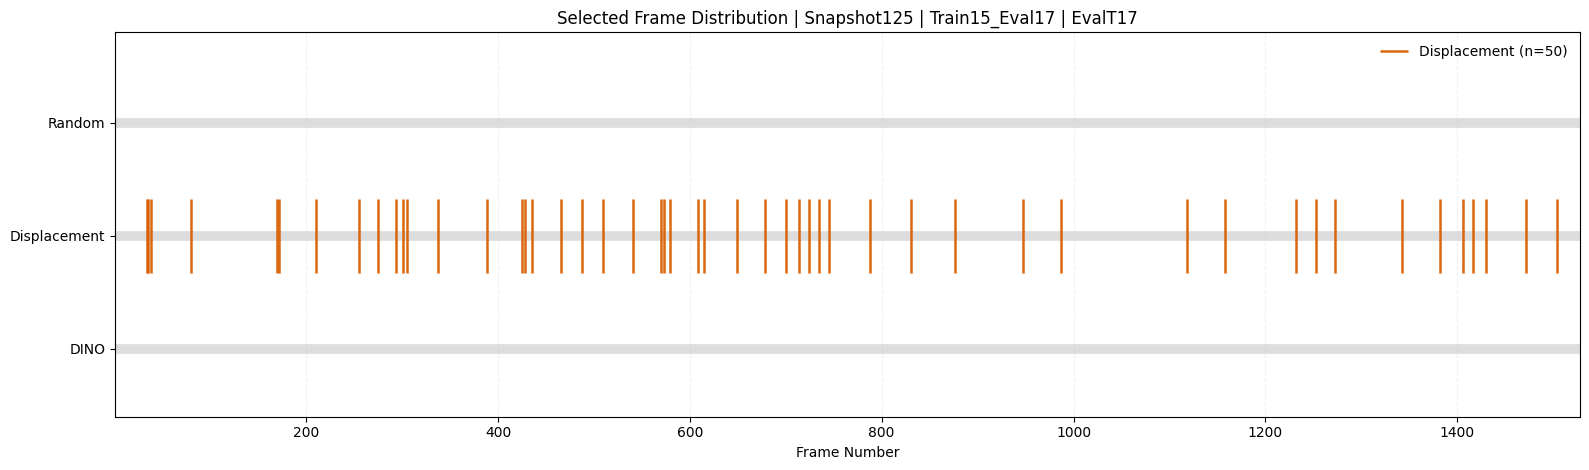


Snapshot125 / Train17_Eval15
  Random: Predicted15_Snapshot125-RandomSamples.csv
  Displacement: Predicted15_Snapshot125-DisplacementSamples.csv
  DINO: Predicted15_Snapshot125-DinoSamples.csv


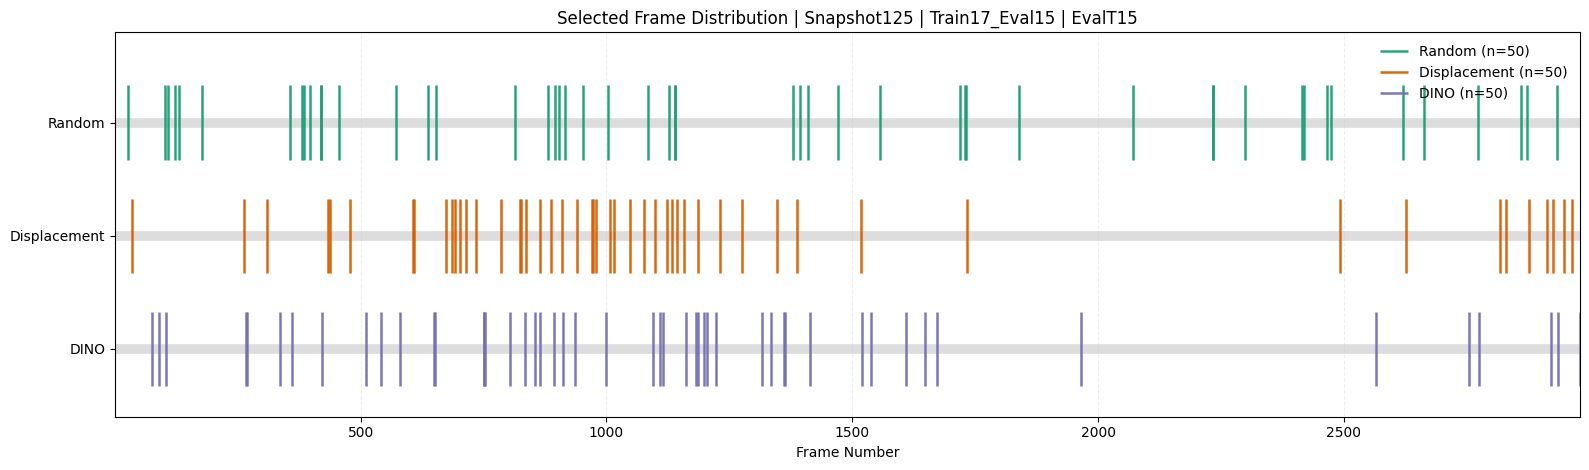

In [79]:
# Visualization 1 from exported sample CSVs (one snapshot)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMPLES_ROOT = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate"
)

# Use only one snapshot as requested (125 or 150).
SNAPSHOT = "Snapshot125"

# Truth frame counts used for full timeline length.
TRUTH_PATHS = {
    15: Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv"),
    17: Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv"),
}

METHOD_CFG = {
    "Random": {
        "dir": "RandomFrames",
        "suffix": "-RandomSamples.csv",
        "color": "#1b9e77",
    },
    "Displacement": {
        "dir": "DisplacementDiversity",
        "suffix": "-DisplacementSamples.csv",
        "color": "#d95f02",
    },
    "DINO": {
        "dir": "DinoDiversity",
        "suffix": "-DinoSamples.csv",
        "color": "#7570b3",
    },
}

def _frame_numbers_from_sample_csv(csv_path: Path) -> np.ndarray:
    df = pd.read_csv(csv_path)
    if "image_path" not in df.columns:
        # Fallback: if no image_path, use row positions as 1-based labels.
        return np.arange(1, len(df) + 1, dtype=int)

    frame_nums = []
    pattern = re.compile(r"\.(\d{4})\.(?:jpg|jpeg|png|tif|tiff)$", flags=re.IGNORECASE)
    for p in df["image_path"].astype(str):
        m = pattern.search(p)
        if m:
            frame_nums.append(int(m.group(1)))

    if not frame_nums:
        return np.array([], dtype=int)
    return np.sort(np.unique(np.asarray(frame_nums, dtype=int)))

def _discover_csvs_for_snapshot(snapshot: str):
    # Returns: {method: {train_eval_folder: csv_path}}
    out = {}
    for method, cfg in METHOD_CFG.items():
        base = SAMPLES_ROOT / cfg["dir"] / snapshot
        per_train_eval = {}
        if base.exists():
            for train_eval_dir in sorted([p for p in base.iterdir() if p.is_dir()]):
                matches = sorted(train_eval_dir.glob(f"*{cfg['suffix']}"))
                if matches:
                    per_train_eval[train_eval_dir.name] = matches[0]
        out[method] = per_train_eval
    return out

def _eval_trial_from_train_eval_name(name: str):
    m = re.search(r"Eval(\d+)", name)
    return int(m.group(1)) if m else None

method_csvs = _discover_csvs_for_snapshot(SNAPSHOT)

# Plot each train/eval folder found in any method for this snapshot.
all_train_eval = sorted(set().union(*[set(v.keys()) for v in method_csvs.values()]))

if not all_train_eval:
    print(f"No sample CSVs found under snapshot: {SNAPSHOT}")
else:
    for train_eval in all_train_eval:
        eval_trial = _eval_trial_from_train_eval_name(train_eval)
        if eval_trial not in TRUTH_PATHS:
            print(f"Skipping {train_eval}: cannot determine Eval trial.")
            continue

        truth_df = pd.read_csv(TRUTH_PATHS[eval_trial])
        total_frames = int(len(truth_df))

        frame_sets = {}
        labels_for_print = []
        for method, cfg in METHOD_CFG.items():
            csv_path = method_csvs.get(method, {}).get(train_eval)
            if csv_path is None:
                frame_sets[method] = np.array([], dtype=int)
                labels_for_print.append(f"{method}: MISSING")
                continue
            frame_sets[method] = _frame_numbers_from_sample_csv(csv_path)
            labels_for_print.append(f"{method}: {csv_path.name}")

        fig, ax = plt.subplots(figsize=(16, 4.8))
        methods = list(METHOD_CFG.keys())
        y_positions = np.arange(len(methods), 0, -1)

        for method, y in zip(methods, y_positions):
            ax.hlines(y=y, xmin=1, xmax=total_frames, color="#c7c7c7", linewidth=7, alpha=0.6)
            selected = frame_sets[method]
            if selected.size > 0:
                ax.vlines(
                    selected,
                    y - 0.33,
                    y + 0.33,
                    color=METHOD_CFG[method]["color"],
                    linewidth=1.8,
                    alpha=0.95,
                    label=f"{method} (n={selected.size})",
                )

        ax.set_xlim(1, max(total_frames, 1))
        ax.set_ylim(0.4, len(methods) + 0.8)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(methods)
        ax.set_xlabel("Frame Number")
        ax.set_title(f"Selected Frame Distribution | {SNAPSHOT} | {train_eval} | EvalT{eval_trial}")
        ax.grid(axis="x", alpha=0.2, linestyle="--")

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if by_label:
            ax.legend(by_label.values(), by_label.keys(), loc="upper right", frameon=False)

        print(f"\n{SNAPSHOT} / {train_eval}")
        for line in labels_for_print:
            print(" ", line)

        plt.tight_layout()
        plt.show()


Summary for Snapshot125:
  Random: n=100 | files=['Predicted17_Snapshot125-RandomSamples.csv', 'Predicted15_Snapshot125-RandomSamples.csv']
  Displacement: n=100 | files=['Predicted17_Snapshot125-DisplacementSamples.csv', 'Predicted15_Snapshot125-DisplacementSamples.csv']
  DINO: n=50 | files=['Predicted15_Snapshot125-DinoSamples.csv']


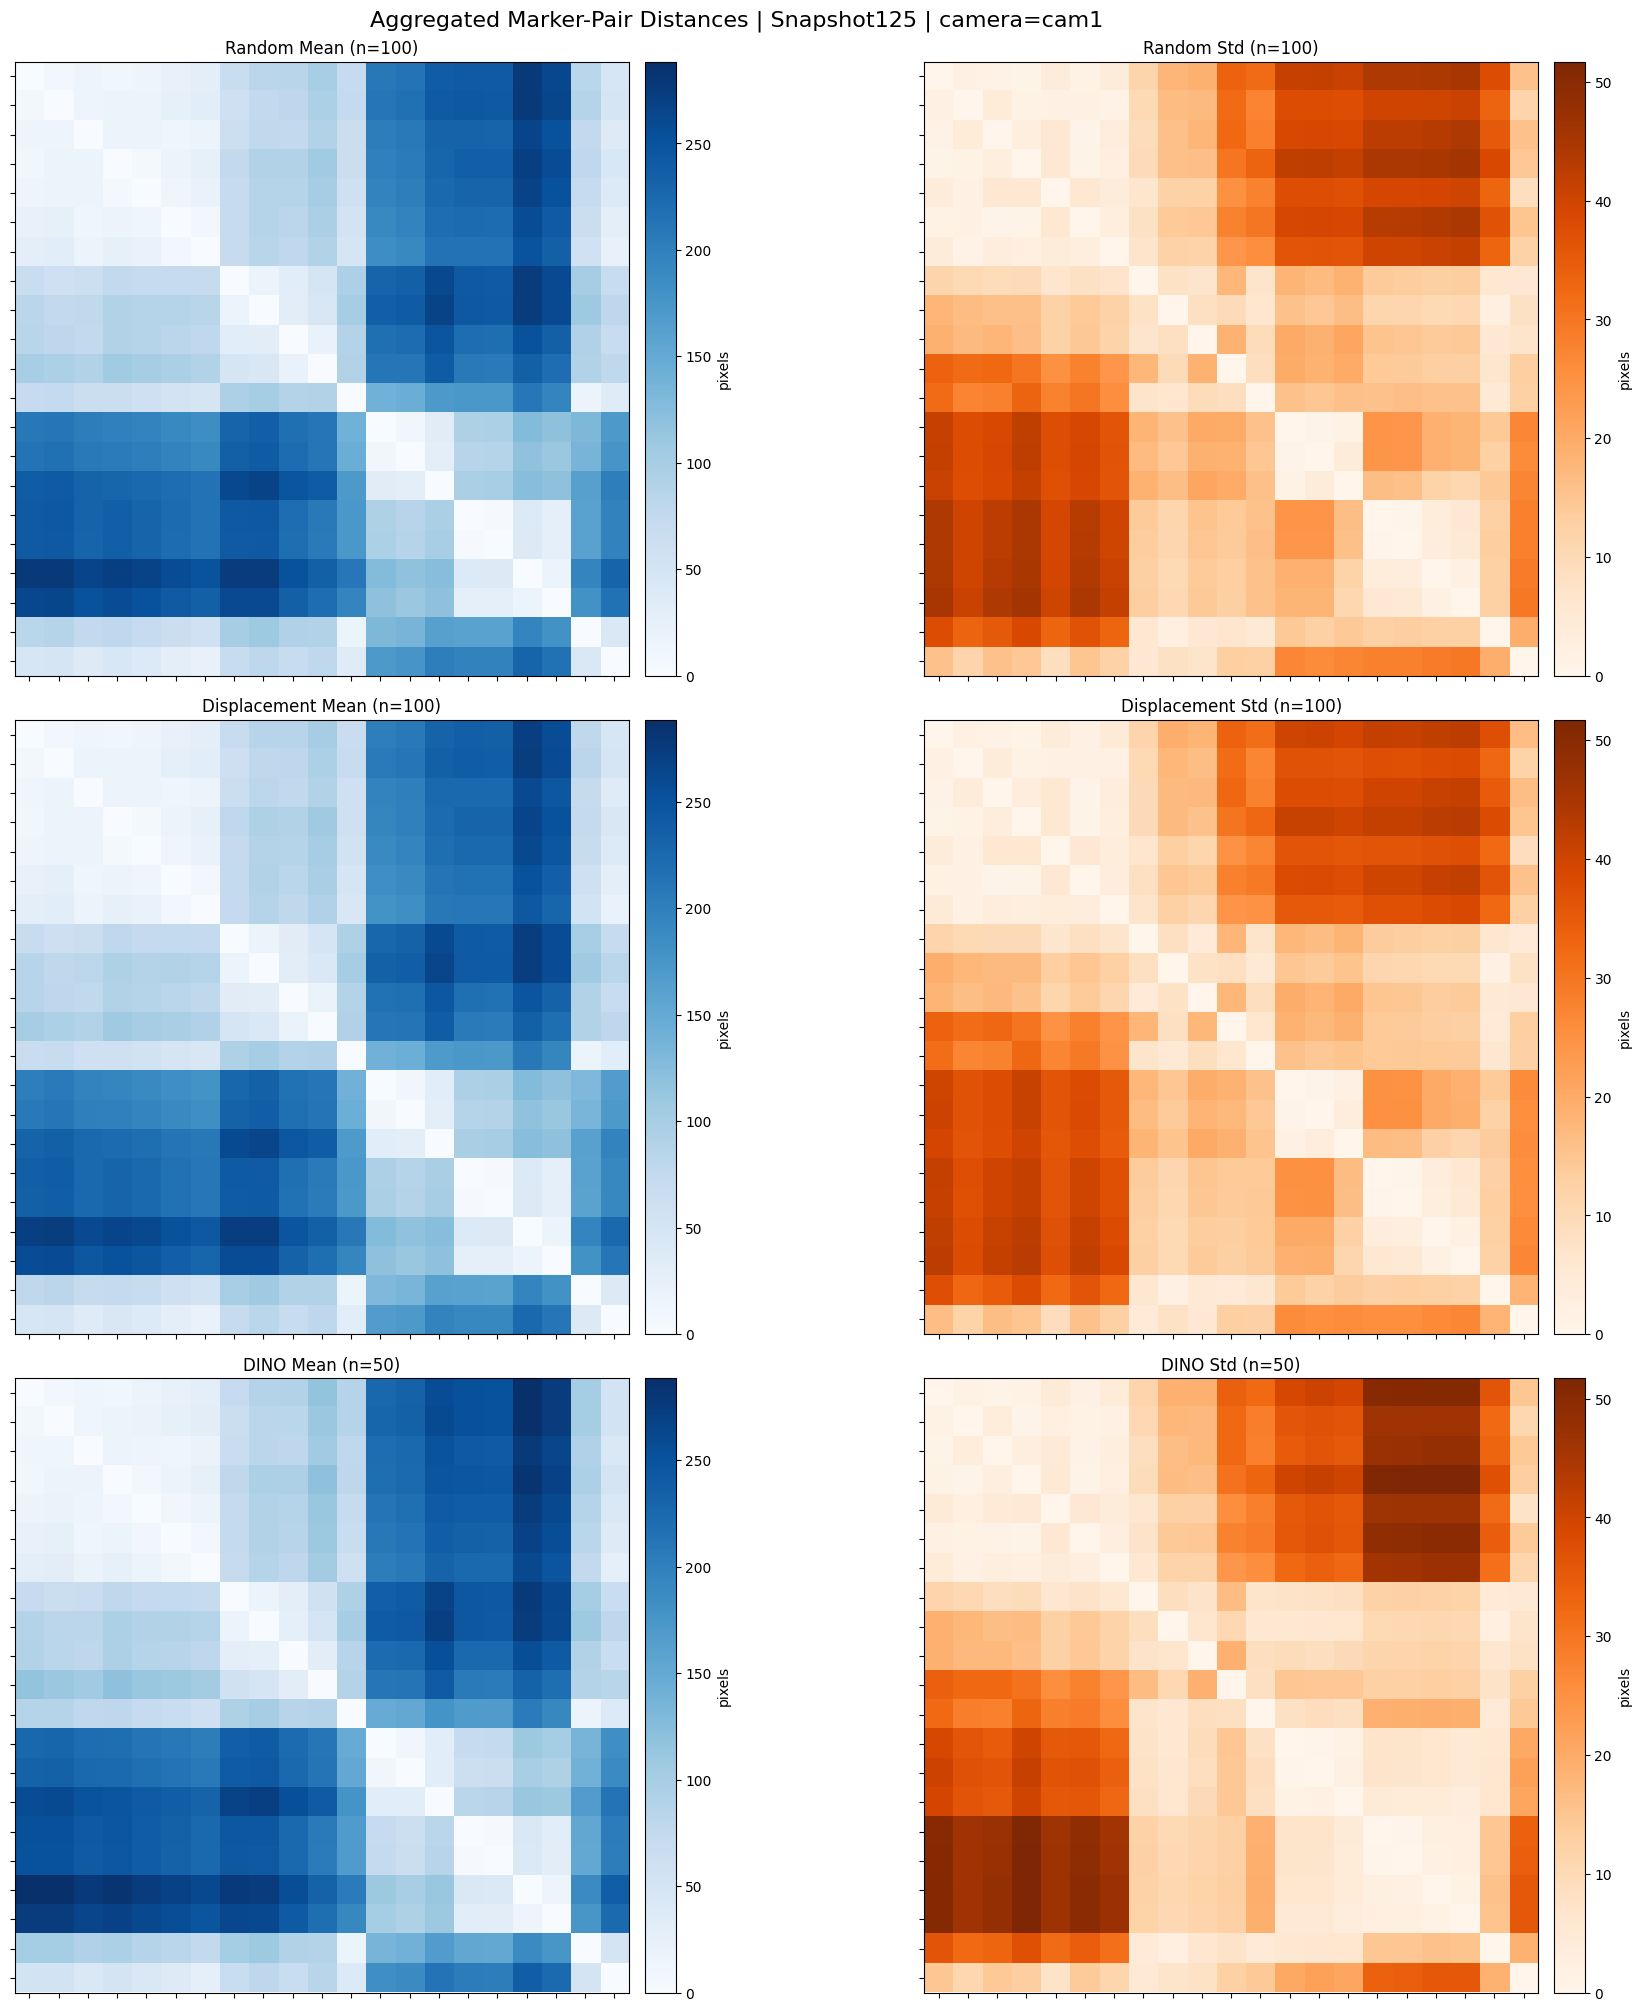

In [91]:
# Visualization 3 (3x2): rows=metric, cols=(Mean, Std), for one snapshot

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMPLES_ROOT = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate"
)

METHOD_CFG = {
    "Random": {
        "dir": "RandomFrames",
        "suffix": "-RandomSamples.csv",
        "cmap_mean": "Blues",
        "cmap_std": "Oranges",
    },
    "Displacement": {
        "dir": "DisplacementDiversity",
        "suffix": "-DisplacementSamples.csv",
        "cmap_mean": "Blues",
        "cmap_std": "Oranges",
    },
    "DINO": {
        "dir": "DinoDiversity",
        "suffix": "-DinoSamples.csv",
        "cmap_mean": "Blues",
        "cmap_std": "Oranges",
    },
}

METRICS = ["Random", "Displacement", "DINO"]
SNAPSHOT = "Snapshot125"
TRAIN_EVALS = ["Train15_Eval17", "Train17_Eval15"]


def _find_csv(method: str, snapshot: str, train_eval: str):
    cfg = METHOD_CFG[method]
    folder = SAMPLES_ROOT / cfg["dir"] / snapshot / train_eval
    if not folder.exists():
        return None
    matches = sorted(folder.glob(f"*{cfg['suffix']}"))
    return matches[0] if matches else None


def _load_combined_df(method: str, snapshot: str):
    frames = []
    found = []
    for te in TRAIN_EVALS:
        csv_path = _find_csv(method, snapshot, te)
        if csv_path is not None:
            d = pd.read_csv(csv_path).copy()
            d["_source_train_eval"] = te
            frames.append(d)
            found.append(csv_path.name)
    if not frames:
        return None, found
    return pd.concat(frames, axis=0, ignore_index=True), found


def _marker_pairs(df: pd.DataFrame, camera: str = "cam1"):
    pat_x = re.compile(rf"(.+?)_{camera}_X$")
    pat_y = re.compile(rf"(.+?)_{camera}_Y$")
    x_map, y_map = {}, {}

    for c in df.columns:
        cs = str(c)
        mx = pat_x.match(cs)
        my = pat_y.match(cs)
        if mx:
            x_map[mx.group(1)] = cs
        if my:
            y_map[my.group(1)] = cs

    markers = sorted(set(x_map).intersection(y_map))
    return [(m, x_map[m], y_map[m]) for m in markers]


def _distance_cube(df: pd.DataFrame, pairs):
    n_frames = len(df)
    n_markers = len(pairs)
    cube = np.full((n_frames, n_markers, n_markers), np.nan, dtype=float)

    for fi in range(n_frames):
        row = df.iloc[fi]
        coords = np.full((n_markers, 2), np.nan, dtype=float)

        for mi, (_, x_col, y_col) in enumerate(pairs):
            x = pd.to_numeric(row.get(x_col, np.nan), errors="coerce")
            y = pd.to_numeric(row.get(y_col, np.nan), errors="coerce")
            if np.isfinite(x) and np.isfinite(y):
                coords[mi, 0] = float(x)
                coords[mi, 1] = float(y)

        valid = np.isfinite(coords[:, 0]) & np.isfinite(coords[:, 1])
        if not np.any(valid):
            continue

        diff = coords[:, None, :] - coords[None, :, :]
        dist = np.sqrt(np.sum(diff * diff, axis=2))
        valid_pair = valid[:, None] & valid[None, :]
        dist[~valid_pair] = np.nan
        cube[fi] = dist

    return cube


def _aggregate_mean_std(df: pd.DataFrame, camera: str = "cam1"):
    pairs = _marker_pairs(df, camera=camera)
    if not pairs:
        return None, None, []

    cube = _distance_cube(df, pairs)
    mean_m = np.nanmean(cube, axis=0)
    std_m = np.nanstd(cube, axis=0)
    labels = [p[0] for p in pairs]
    return mean_m, std_m, labels


def _plot_3x2(snapshot: str = "Snapshot125", camera: str = "cam1"):
    # collect all data first so each column uses consistent color scale
    metric_data = {}
    all_mean_max = []
    all_std_max = []

    for method in METRICS:
        df, found_files = _load_combined_df(method, snapshot)
        if df is None or len(df) == 0:
            metric_data[method] = {"ok": False, "reason": "No CSVs found", "files": found_files}
            continue

        mean_m, std_m, labels = _aggregate_mean_std(df, camera=camera)
        if mean_m is None:
            metric_data[method] = {"ok": False, "reason": f"No {camera} marker columns", "files": found_files}
            continue

        all_mean_max.append(float(np.nanmax(mean_m)) if np.isfinite(np.nanmax(mean_m)) else 0.0)
        all_std_max.append(float(np.nanmax(std_m)) if np.isfinite(np.nanmax(std_m)) else 0.0)

        metric_data[method] = {
            "ok": True,
            "mean": mean_m,
            "std": std_m,
            "labels": labels,
            "n_frames": len(df),
            "files": found_files,
        }

    mean_vmax = max(all_mean_max) if all_mean_max else 1.0
    std_vmax = max(all_std_max) if all_std_max else 1.0
    if mean_vmax <= 0:
        mean_vmax = 1.0
    if std_vmax <= 0:
        std_vmax = 1.0

    fig, axes = plt.subplots(3, 2, figsize=(18, 20), constrained_layout=True)
    fig.suptitle(f"Aggregated Marker-Pair Distances | {snapshot} | camera={camera}", fontsize=16)

    for r, method in enumerate(METRICS):
        cfg = METHOD_CFG[method]
        d = metric_data[method]

        ax_mean = axes[r, 0]
        ax_std = axes[r, 1]

        if not d["ok"]:
            ax_mean.text(0.5, 0.5, d["reason"], ha="center", va="center")
            ax_std.text(0.5, 0.5, d["reason"], ha="center", va="center")
            ax_mean.set_title(f"{method} Mean")
            ax_std.set_title(f"{method} Std")
            ax_mean.set_axis_off()
            ax_std.set_axis_off()
            continue

        im_mean = ax_mean.imshow(d["mean"], cmap=cfg["cmap_mean"], vmin=0.0, vmax=mean_vmax)
        ax_mean.set_title(f"{method} Mean (n={d['n_frames']})")
        ax_mean.set_xticks(range(len(d["labels"])))
        ax_mean.set_yticks(range(len(d["labels"])))
        ax_mean.set_xticklabels("", rotation=90, fontsize=6)
        ax_mean.set_yticklabels("", fontsize=6)
        cbm = fig.colorbar(im_mean, ax=ax_mean, fraction=0.046, pad=0.02)
        cbm.set_label("pixels")

        im_std = ax_std.imshow(d["std"], cmap=cfg["cmap_std"], vmin=0.0, vmax=std_vmax)
        ax_std.set_title(f"{method} Std (n={d['n_frames']})")
        ax_std.set_xticks(range(len(d["labels"])))
        ax_std.set_yticks(range(len(d["labels"])))
        ax_std.set_xticklabels("", rotation=90, fontsize=6)
        ax_std.set_yticklabels("", fontsize=6)
        cbs = fig.colorbar(im_std, ax=ax_std, fraction=0.046, pad=0.02)
        cbs.set_label("pixels")

    print(f"\nSummary for {snapshot}:")
    for method in METRICS:
        d = metric_data[method]
        if d["ok"]:
            print(f"  {method}: n={d['n_frames']} | files={d['files']}")
        else:
            print(f"  {method}: {d['reason']} | files={d.get('files', [])}")

    plt.show()


_plot_3x2(snapshot=SNAPSHOT, camera="cam1")

In [ ]:
# Lets get the corresponding truth values for the selected frames 
# we have the truth datasets for both trials, so we can match based on the Eval trial in the folder name.
def _load_truth_for_eval_trial(eval_trial: int):
    path = TRUTH_PATHS.get(eval_trial)
    if path is None or not path.exists():
        print(f"No truth CSV found for Eval trial {eval_trial}")
        return None
    return pd.read_csv(path)
print([_load_truth_for_eval_trial(eval) for eval in [15, 17]])

# Now we must subset the truth dataframes to only the selected frames for each method, and then we can compute some error metrics (like mean distance error) against the predicted points in the sample CSVs. This will allow us to compare how well the different selection methods are doing in terms of picking frames that have high or low error compared to the ground truth.



[      Cranium_Left_Anterior_cam1_X  Cranium_Left_Anterior_cam1_Y  \
0                       374.051042                    177.387317   
1                       373.994566                    177.312765   
2                       373.919796                    177.280367   
3                       374.051652                    177.362585   
4                       374.062160                    177.449801   
...                            ...                           ...   
2975                    361.500000                    160.000000   
2976                    361.500000                    160.000000   
2977                    361.500000                    160.000000   
2978                    361.500000                    160.000000   
2979                    361.500000                    160.000000   

      Cranium_Left_Anterior_cam2_X  Cranium_Left_Anterior_cam2_Y  \
0                       254.926150                    192.048370   
1                       254.770071            

In [96]:
# Continue from your truth-loading block:
# Build truth-matched subsets + error metrics for each method/train-eval/snapshot,
# and save truth subsets + per-frame errors next to each sample CSV.

import re
from pathlib import Path
import numpy as np
import pandas as pd

SAMPLES_ROOT = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate"
)

METHOD_CFG = {
    "Random": {"dir": "RandomFrames", "suffix": "-RandomSamples.csv"},
    "Displacement": {"dir": "DisplacementDiversity", "suffix": "-DisplacementSamples.csv"},
    "DINO": {"dir": "DinoDiversity", "suffix": "-DinoSamples.csv"},
}

SNAPSHOT = ["Snapshot125", "Snapshot150"]
TRAIN_EVALS = ["Train15_Eval17", "Train17_Eval15"]

TRUTH_PATHS = {
    15: Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv"),
    17: Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv"),
}

def _load_truth_for_eval_trial(eval_trial: int):
    path = TRUTH_PATHS.get(eval_trial)
    if path is None or not path.exists():
        print(f"No truth CSV found for Eval trial {eval_trial}")
        return None
    return pd.read_csv(path)

def _parse_eval_trial(train_eval: str):
    m = re.search(r"Eval(\d+)", train_eval)
    return int(m.group(1)) if m else None

def _find_sample_csv(method: str, snapshot: str, train_eval: str):
    cfg = METHOD_CFG[method]
    folder = SAMPLES_ROOT / cfg["dir"] / snapshot / train_eval
    if not folder.exists():
        return None
    matches = sorted(folder.glob(f"*{cfg['suffix']}"))
    return matches[0] if matches else None

def _extract_frame_num(image_path: str):
    if not isinstance(image_path, str):
        return None
    m = re.search(r"\.(\d{4})\.(jpg|jpeg|png|tif|tiff)$", image_path, flags=re.IGNORECASE)
    return int(m.group(1)) if m else None  # 1-based frame number

def _xy_pairs(df: pd.DataFrame, camera: str):
    x_pat = re.compile(rf"(.+?)_{camera}_X$")
    y_pat = re.compile(rf"(.+?)_{camera}_Y$")
    x_map, y_map = {}, {}
    for c in df.columns:
        cs = str(c)
        mx = x_pat.match(cs)
        my = y_pat.match(cs)
        if mx:
            x_map[mx.group(1)] = cs
        if my:
            y_map[my.group(1)] = cs
    keys = sorted(set(x_map).intersection(y_map))
    return [(x_map[k], y_map[k]) for k in keys]

def _mean_point_error(pred_row, truth_row, pairs):
    errs = []
    for x_col, y_col in pairs:
        px = pd.to_numeric(pred_row.get(x_col, np.nan), errors="coerce")
        py = pd.to_numeric(pred_row.get(y_col, np.nan), errors="coerce")
        tx = pd.to_numeric(truth_row.get(x_col, np.nan), errors="coerce")
        ty = pd.to_numeric(truth_row.get(y_col, np.nan), errors="coerce")
        if np.isfinite(px) and np.isfinite(py) and np.isfinite(tx) and np.isfinite(ty):
            errs.append(float(np.hypot(px - tx, py - ty)))
    return float(np.mean(errs)) if errs else np.nan

def evaluate_sample_csv(sample_csv: Path, truth_df: pd.DataFrame):
    pred = pd.read_csv(sample_csv).copy()

    cam1_pairs = _xy_pairs(pred, "cam1")
    cam2_pairs = _xy_pairs(pred, "cam2")
    all_pairs = cam1_pairs + cam2_pairs

    rows = []
    for i, row in pred.iterrows():
        frame_num = _extract_frame_num(row.get("image_path", None))
        if frame_num is None:
            continue
        truth_idx = frame_num - 1
        if truth_idx < 0 or truth_idx >= len(truth_df):
            continue

        truth_row = truth_df.iloc[truth_idx]
        rows.append(
            {
                "pred_row_idx": int(i),
                "frame_num": int(frame_num),
                "mean_err_cam1": _mean_point_error(row, truth_row, cam1_pairs) if cam1_pairs else np.nan,
                "mean_err_cam2": _mean_point_error(row, truth_row, cam2_pairs) if cam2_pairs else np.nan,
                "mean_err_all": _mean_point_error(row, truth_row, all_pairs) if all_pairs else np.nan,
            }
        )

    per_frame = pd.DataFrame(rows).sort_values("frame_num").reset_index(drop=True) if rows else pd.DataFrame(
        columns=["pred_row_idx", "frame_num", "mean_err_cam1", "mean_err_cam2", "mean_err_all"]
    )

    summary = {
        "n_frames_evaluated": int(len(per_frame)),
        "mean_err_cam1": float(np.nanmean(per_frame["mean_err_cam1"])) if len(per_frame) else np.nan,
        "mean_err_cam2": float(np.nanmean(per_frame["mean_err_cam2"])) if len(per_frame) else np.nan,
        "mean_err_all": float(np.nanmean(per_frame["mean_err_all"])) if len(per_frame) else np.nan,
        "median_err_all": float(np.nanmedian(per_frame["mean_err_all"])) if len(per_frame) else np.nan,
        "std_err_all": float(np.nanstd(per_frame["mean_err_all"])) if len(per_frame) else np.nan,
    }
    return per_frame, summary

def build_truth_subset_for_sample(sample_csv: Path, truth_df: pd.DataFrame):
    pred = pd.read_csv(sample_csv).copy()
    out_rows = []

    for i, row in pred.iterrows():
        frame_num = _extract_frame_num(row.get("image_path", None))
        if frame_num is None:
            continue
        truth_idx = frame_num - 1
        if truth_idx < 0 or truth_idx >= len(truth_df):
            continue

        truth_row = truth_df.iloc[truth_idx].copy()
        truth_row["pred_row_idx"] = int(i)
        truth_row["frame_num"] = int(frame_num)
        truth_row["image_path"] = row.get("image_path", None)
        out_rows.append(truth_row)

    return pd.DataFrame(out_rows).reset_index(drop=True) if out_rows else pd.DataFrame()

def _swap_suffix(filename: str, old_suffix: str, new_suffix: str):
    if filename.endswith(old_suffix):
        return filename[: -len(old_suffix)] + new_suffix
    return Path(filename).stem + new_suffix

# Run evaluation + save outputs for all methods/snapshots/train-eval
all_summaries = []
per_frame_results = {}

for method in METHOD_CFG.keys():
    method_suffix = METHOD_CFG[method]["suffix"]

    for snapshot in SNAPSHOT:
        for te in TRAIN_EVALS:
            csv_path = _find_sample_csv(method, snapshot, te)

            if csv_path is None:
                all_summaries.append(
                    {
                        "method": method,
                        "snapshot": snapshot,
                        "train_eval": te,
                        "status": "missing_csv",
                    }
                )
                continue

            eval_trial = _parse_eval_trial(te)
            truth_df = _load_truth_for_eval_trial(eval_trial) if eval_trial is not None else None
            if truth_df is None:
                all_summaries.append(
                    {
                        "method": method,
                        "snapshot": snapshot,
                        "train_eval": te,
                        "status": "missing_truth",
                        "csv": csv_path.name,
                    }
                )
                continue

            # 1) Save truth subset next to sample CSV
            truth_subset = build_truth_subset_for_sample(csv_path, truth_df)
            truth_subset_name = _swap_suffix(csv_path.name, method_suffix, "-TruthSubset.csv")
            truth_subset_path = csv_path.parent / truth_subset_name
            truth_subset.to_csv(truth_subset_path, index=False)

            # 2) Compute + save per-frame error table
            per_frame, summary = evaluate_sample_csv(csv_path, truth_df)
            per_frame_name = _swap_suffix(csv_path.name, method_suffix, "-PerFrameErrors.csv")
            per_frame_path = csv_path.parent / per_frame_name
            per_frame.to_csv(per_frame_path, index=False)

            per_frame_results[(method, snapshot, te)] = per_frame

            all_summaries.append(
                {
                    "method": method,
                    "snapshot": snapshot,
                    "train_eval": te,
                    "status": "ok",
                    "csv": csv_path.name,
                    "truth_subset_csv": truth_subset_name,
                    "per_frame_errors_csv": per_frame_name,
                    **summary,
                }
            )

summary_df = pd.DataFrame(all_summaries).sort_values(["method", "snapshot", "train_eval"])
display(summary_df)

,method,snapshot,train_eval,status,csv,truth_subset_csv,per_frame_errors_csv,n_frames_evaluated,mean_err_cam1,mean_err_cam2,mean_err_all,median_err_all,std_err_all
8,DINO,Snapshot125,Train15_Eval17,missing_csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,DINO,Snapshot125,Train17_Eval15,ok,Predicted15_Snapshot125-DinoSamples.csv,Predicted15_Snapshot125-TruthSubset.csv,Predicted15_Snapshot125-PerFrameErrors.csv,50.0,4.512037,2.815964,3.664001,3.936036,1.061624
10,DINO,Snapshot150,Train15_Eval17,missing_csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,DINO,Snapshot150,Train17_Eval15,ok,Predicted15_Snapshot150-DinoSamples.csv,Predicted15_Snapshot150-TruthSubset.csv,Predicted15_Snapshot150-PerFrameErrors.csv,50.0,4.527255,2.878747,3.703001,3.938008,1.038538
4,Displacement,Snapshot125,Train15_Eval17,ok,Predicted17_Snapshot125-DisplacementSamples.csv,Predicted17_Snapshot125-TruthSubset.csv,Predicted17_Snapshot125-PerFrameErrors.csv,50.0,2.705553,2.285559,2.495556,2.469547,0.391897
5,Displacement,Snapshot125,Train17_Eval15,ok,Predicted15_Snapshot125-DisplacementSamples.csv,Predicted15_Snapshot125-TruthSubset.csv,Predicted15_Snapshot125-PerFrameErrors.csv,50.0,4.255856,2.824093,3.539974,3.023856,1.013057
6,Displacement,Snapshot150,Train15_Eval17,ok,Predicted17_Snapshot150-DisplacementSamples.csv,Predicted17_Snapshot150-TruthSubset.csv,Predicted17_Snapshot150-PerFrameErrors.csv,50.0,2.733129,2.306341,2.519735,2.472786,0.488211
7,Displacement,Snapshot150,Train17_Eval15,ok,Predicted15_Snapshot150-DisplacementSamples.csv,Predicted15_Snapshot150-TruthSubset.csv,Predicted15_Snapshot150-PerFrameErrors.csv,50.0,4.304682,2.881985,3.593333,3.082170,1.011074
0,Random,Snapshot125,Train15_Eval17,ok,Predicted17_Snapshot125-RandomSamples.csv,Predicted17_Snapshot125-TruthSubset.csv,Predicted17_Snapshot125-PerFrameErrors.csv,0.0,NaN,NaN,NaN,NaN,NaN
1,Random,Snapshot125,Train17_Eval15,ok,Predicted15_Snapshot125-RandomSamples.csv,Predicted15_Snapshot125-TruthSubset.csv,Predicted15_Snapshot125-PerFrameErrors.csv,50.0,5.035489,2.445881,3.740685,4.112337,1.028498


In [ ]:
# Interactive frame viewer: method/snapshot/train-eval + camera + point toggles
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

# =========================
# Config (uses existing globals if available)
# =========================
VIEWER_SAMPLES_ROOT = Path(
    globals().get(
        "SAMPLES_ROOT",
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate",
    )
)

VIEWER_METHOD_CFG = {
    "Random": {"dir": "RandomFrames", "suffix": "-RandomSamples.csv"},
    "Displacement": {"dir": "DisplacementDiversity", "suffix": "-DisplacementSamples.csv"},
    "DINO": {"dir": "DinoDiversity", "suffix": "-DinoSamples.csv"},
}

VIEWER_TRUTH_PATHS = {
    15: Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv"
    ),
    17: Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv"
    ),
}

_FRAME_RE = re.compile(r"\.(\d{4})\.(jpg|jpeg|png|tif|tiff)$", flags=re.IGNORECASE)

# =========================
# Helpers
# =========================
def _parse_eval_trial(train_eval_name: str):
    m = re.search(r"Eval(\d+)", str(train_eval_name))
    return int(m.group(1)) if m else None

def _discover_snapshots(method_name: str):
    base = VIEWER_SAMPLES_ROOT / VIEWER_METHOD_CFG[method_name]["dir"]
    if not base.exists():
        return []
    return sorted([p.name for p in base.iterdir() if p.is_dir()])

def _discover_train_evals(method_name: str, snapshot_name: str):
    base = VIEWER_SAMPLES_ROOT / VIEWER_METHOD_CFG[method_name]["dir"] / snapshot_name
    if not base.exists():
        return []
    out = []
    suffix = VIEWER_METHOD_CFG[method_name]["suffix"]
    for p in sorted([x for x in base.iterdir() if x.is_dir()]):
        if list(p.glob(f"*{suffix}")):
            out.append(p.name)
    return out

def _find_sample_csv(method_name: str, snapshot_name: str, train_eval_name: str):
    cfg = VIEWER_METHOD_CFG[method_name]
    folder = VIEWER_SAMPLES_ROOT / cfg["dir"] / snapshot_name / train_eval_name
    if not folder.exists():
        return None
    matches = sorted(folder.glob(f"*{cfg['suffix']}"))
    return matches[0] if matches else None

def _swap_suffix(filename: str, old_suffix: str, new_suffix: str):
    if filename.endswith(old_suffix):
        return filename[: -len(old_suffix)] + new_suffix
    return Path(filename).stem + new_suffix

def _extract_frame_num(image_path_val):
    if not isinstance(image_path_val, str):
        return np.nan
    m = _FRAME_RE.search(image_path_val)
    return int(m.group(1)) if m else np.nan

def _xy_map_for_camera(df: pd.DataFrame, camera: str):
    out = {}
    x_pat = re.compile(rf"(.+?)_{camera}_X$")
    y_pat = re.compile(rf"(.+?)_{camera}_Y$")
    x_map, y_map = {}, {}
    for c in df.columns:
        cs = str(c)
        mx = x_pat.match(cs)
        my = y_pat.match(cs)
        if mx:
            x_map[mx.group(1)] = cs
        if my:
            y_map[my.group(1)] = cs
    for marker in sorted(set(x_map).intersection(y_map)):
        out[marker] = (x_map[marker], y_map[marker])
    return out

def _path_for_camera(image_path_val: str, camera: str):
    if not isinstance(image_path_val, str) or not image_path_val:
        return image_path_val

    if camera == "cam1":
        candidate = re.sub(r"Cam2_", "Cam1_", image_path_val)
        candidate = re.sub(r"cam2_", "cam1_", candidate)
    else:
        candidate = re.sub(r"Cam1_", "Cam2_", image_path_val)
        candidate = re.sub(r"cam1_", "cam2_", candidate)

    # Use converted path when available, otherwise fall back to original.
    if isinstance(candidate, str) and os.path.isfile(candidate):
        return candidate
    return image_path_val

def _safe_float(v):
    return pd.to_numeric(v, errors="coerce")

# =========================
# UI + State
# =========================
state = {
    "pred_df": None,
    "truth_df": None,
    "errors_df": None,
    "point_map": {},
    "sample_csv": None,
}

method_dd = widgets.Dropdown(
    options=list(VIEWER_METHOD_CFG.keys()),
    value="Random",
    description="Method:",
    layout=widgets.Layout(width="240px"),
)

snapshot_dd = widgets.Dropdown(
    options=[],
    description="Snapshot:",
    layout=widgets.Layout(width="220px"),
)

train_eval_dd = widgets.Dropdown(
    options=[],
    description="Train/Eval:",
    layout=widgets.Layout(width="240px"),
)

camera_dd = widgets.Dropdown(
    options=[("cam1", "cam1"), ("cam2", "cam2")],
    value="cam1",
    description="Camera:",
    layout=widgets.Layout(width="180px"),
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=0,
    step=1,
    description="Selected idx:",
    continuous_update=False,
    readout=True,
    layout=widgets.Layout(width="520px"),
)

show_pred_cb = widgets.Checkbox(value=True, description="Show predicted", indent=False)
show_truth_cb = widgets.Checkbox(value=True, description="Show truth", indent=False)
show_labels_cb = widgets.Checkbox(value=False, description="Show point labels", indent=False)

point_select = widgets.SelectMultiple(
    options=[],
    value=tuple(),
    description="Points:",
    rows=12,
    layout=widgets.Layout(width="430px"),
)

btn_all = widgets.Button(description="Select all points", button_style="")
btn_none = widgets.Button(description="Clear points", button_style="")
status_html = widgets.HTML(value="")
plot_out = widgets.Output()

def _set_status(msg, color="#444"):
    status_html.value = f"<span style='color:{color}; font-family:monospace'>{msg}</span>"

def _refresh_options():
    m = method_dd.value
    snaps = _discover_snapshots(m)
    snapshot_dd.options = snaps
    snapshot_dd.value = snaps[0] if snaps else None

    tes = _discover_train_evals(m, snapshot_dd.value) if snapshot_dd.value else []
    train_eval_dd.options = tes
    train_eval_dd.value = tes[0] if tes else None

def _refresh_points_for_camera():
    pred = state["pred_df"]
    if pred is None or len(pred) == 0:
        state["point_map"] = {}
        point_select.options = []
        point_select.value = tuple()
        return

    pmap = _xy_map_for_camera(pred, camera_dd.value)
    point_opts = sorted(pmap.keys())
    state["point_map"] = pmap
    point_select.options = point_opts
    point_select.value = tuple(point_opts)

def _load_combo():
    m = method_dd.value
    s = snapshot_dd.value
    te = train_eval_dd.value

    state["pred_df"] = None
    state["truth_df"] = None
    state["errors_df"] = None
    state["point_map"] = {}
    state["sample_csv"] = None

    if not (m and s and te):
        frame_slider.max = 0
        frame_slider.value = 0
        point_select.options = []
        point_select.value = tuple()
        _set_status("No valid method/snapshot/train-eval combination found.", "#b00020")
        _render()
        return

    sample_csv = _find_sample_csv(m, s, te)
    if sample_csv is None:
        frame_slider.max = 0
        frame_slider.value = 0
        point_select.options = []
        point_select.value = tuple()
        _set_status("Sample CSV missing for selected combination.", "#b00020")
        _render()
        return

    pred = pd.read_csv(sample_csv).copy()
    pred["frame_num"] = pred["image_path"].apply(_extract_frame_num)
    pred = pred[pd.to_numeric(pred["frame_num"], errors="coerce").notna()].copy()
    pred["frame_num"] = pred["frame_num"].astype(int)
    pred = pred.reset_index(drop=True)

    eval_trial = _parse_eval_trial(te)
    truth_path = VIEWER_TRUTH_PATHS.get(eval_trial, None)
    if truth_path is None or not truth_path.exists():
        _set_status(f"Truth CSV missing for Eval{eval_trial}.", "#b00020")
        truth = None
    else:
        truth = pd.read_csv(truth_path)

    # Load per-frame errors (if available)
    cfg = VIEWER_METHOD_CFG[m]
    err_name = _swap_suffix(sample_csv.name, cfg["suffix"], "-PerFrameErrors.csv")
    err_path = sample_csv.parent / err_name
    errors_df = pd.read_csv(err_path) if err_path.exists() else None

    state["pred_df"] = pred
    state["truth_df"] = truth
    state["errors_df"] = errors_df
    state["sample_csv"] = sample_csv

    if len(pred) == 0:
        frame_slider.max = 0
        frame_slider.value = 0
        frame_slider.disabled = True
    else:
        frame_slider.disabled = False
        frame_slider.max = len(pred) - 1
        frame_slider.value = min(frame_slider.value, frame_slider.max)

    _refresh_points_for_camera()
    _set_status(f"Loaded {len(pred)} selected frames from {sample_csv.name}", "#2e7d32")
    _render()

def _render(*_):
    with plot_out:
        plot_out.clear_output(wait=True)

        pred = state["pred_df"]
        truth = state["truth_df"]
        pmap = state["point_map"]
        err = state["errors_df"]

        if pred is None or len(pred) == 0:
            print("No frame data to display for current selection.")
            return

        i = int(frame_slider.value)
        row = pred.iloc[i]
        frame_num = int(row["frame_num"]) if np.isfinite(_safe_float(row["frame_num"])) else None
        image_path = _path_for_camera(str(row.get("image_path", "")), camera_dd.value)

        fig, ax = plt.subplots(figsize=(11, 7))

        if image_path and os.path.isfile(image_path):
            try:
                with Image.open(image_path) as img:
                    ax.imshow(np.asarray(img.convert("RGB")))
            except Exception as exc:
                ax.text(0.5, 0.5, f"Image load failed: {exc}", ha="center", va="center", transform=ax.transAxes)
                ax.set_facecolor("#f2f2f2")
        else:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center", transform=ax.transAxes)
            ax.set_facecolor("#f2f2f2")

        selected_points = list(point_select.value)
        pred_xs, pred_ys = [], []
        truth_xs, truth_ys = [], []

        truth_row = None
        if truth is not None and frame_num is not None:
            idx = frame_num - 1
            if 0 <= idx < len(truth):
                truth_row = truth.iloc[idx]

        for pt in selected_points:
            if pt not in pmap:
                continue
            x_col, y_col = pmap[pt]

            if show_pred_cb.value:
                px = _safe_float(row.get(x_col, np.nan))
                py = _safe_float(row.get(y_col, np.nan))
                if np.isfinite(px) and np.isfinite(py):
                    pred_xs.append(float(px))
                    pred_ys.append(float(py))
                    if show_labels_cb.value:
                        ax.text(float(px), float(py), pt, color="#00BCD4", fontsize=8)

            if show_truth_cb.value and truth_row is not None:
                tx = _safe_float(truth_row.get(x_col, np.nan))
                ty = _safe_float(truth_row.get(y_col, np.nan))
                if np.isfinite(tx) and np.isfinite(ty):
                    truth_xs.append(float(tx))
                    truth_ys.append(float(ty))
                    if show_labels_cb.value:
                        ax.text(float(tx), float(ty), pt, color="#FF3D00", fontsize=8)

        if len(pred_xs):
            ax.scatter(pred_xs, pred_ys, s=10, c="#00BCD4", edgecolors="black", linewidths=0.4, alpha=0.5, label="Predicted")
        if len(truth_xs):
            ax.scatter(truth_xs, truth_ys, s=10, marker="x", c="#FF3D00", linewidths=1.5, alpha=0.5, label="Truth")

        err_txt = ""
        if err is not None and frame_num is not None and "frame_num" in err.columns:
            e = err.loc[err["frame_num"] == frame_num]
            if len(e):
                v = pd.to_numeric(e.iloc[0].get("mean_err_all", np.nan), errors="coerce")
                if np.isfinite(v):
                    err_txt = f" | mean_err_all={float(v):.2f}px"

        ax.set_title(
            f"{method_dd.value} | {snapshot_dd.value} | {train_eval_dd.value} | {camera_dd.value} | selected_idx={i+1}/{len(pred)} | frame={frame_num}{err_txt}"
        )
        ax.axis("off")
        if (len(pred_xs) or len(truth_xs)) and (show_pred_cb.value or show_truth_cb.value):
            ax.legend(loc="upper right", frameon=True)

        plt.tight_layout()
        plt.show()

def _on_method_change(_):
    snaps = _discover_snapshots(method_dd.value)
    snapshot_dd.options = snaps
    snapshot_dd.value = snaps[0] if snaps else None

def _on_snapshot_change(_):
    tes = _discover_train_evals(method_dd.value, snapshot_dd.value) if snapshot_dd.value else []
    train_eval_dd.options = tes
    train_eval_dd.value = tes[0] if tes else None

def _on_camera_change(_):
    _refresh_points_for_camera()
    _render()

def _select_all_points(_):
    point_select.value = tuple(point_select.options)

def _clear_points(_):
    point_select.value = tuple()

# Observe changes
method_dd.observe(_on_method_change, names="value")
snapshot_dd.observe(_on_snapshot_change, names="value")
camera_dd.observe(_on_camera_change, names="value")

for w in [method_dd, snapshot_dd, train_eval_dd]:
    w.observe(lambda ch: _load_combo(), names="value")

for w in [frame_slider, show_pred_cb, show_truth_cb, show_labels_cb, point_select]:
    w.observe(_render, names="value")

btn_all.on_click(_select_all_points)
btn_none.on_click(_clear_points)

# Build initial options and load
_refresh_options()
_load_combo()

controls_top = widgets.HBox([method_dd, snapshot_dd, train_eval_dd, camera_dd])
controls_mid = widgets.HBox([frame_slider])
controls_toggles = widgets.HBox([show_pred_cb, show_truth_cb, show_labels_cb])
controls_points = widgets.HBox([point_select, widgets.VBox([btn_all, btn_none])])

display(widgets.VBox([controls_top, controls_mid, controls_toggles, controls_points, status_html, plot_out]))

### Error across the data

   method     snapshot            model     error
0  Random  Snapshot125  Train17->Eval15  2.894261
1  Random  Snapshot125  Train17->Eval15  2.828575
2  Random  Snapshot125  Train17->Eval15  2.643834
3  Random  Snapshot125  Train17->Eval15  2.624312
4  Random  Snapshot125  Train17->Eval15  2.611975


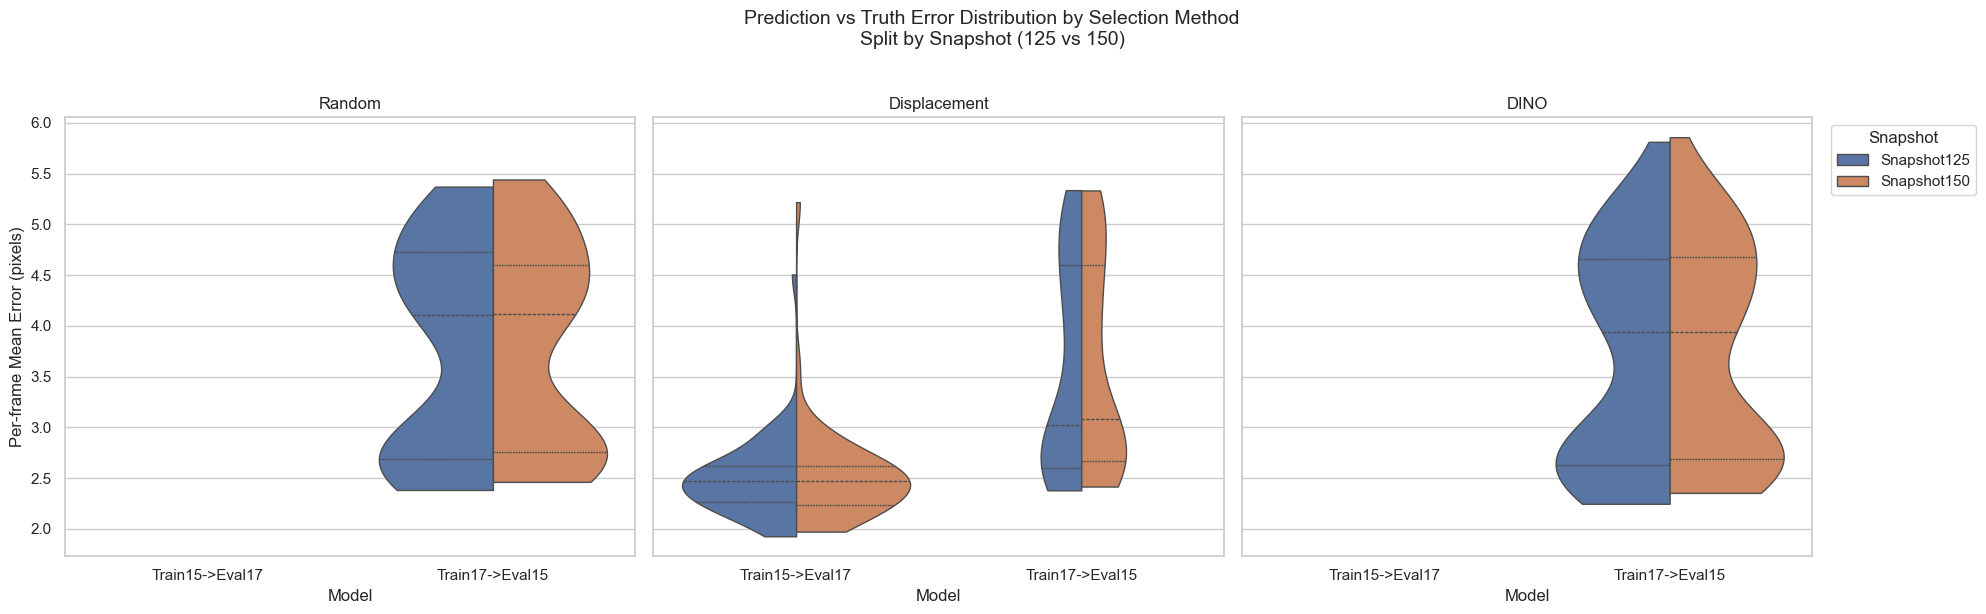

Missing or incomplete combinations:
  ('DINO', 'Snapshot125', 'Train15_Eval17')
  ('DINO', 'Snapshot150', 'Train15_Eval17')


In [2]:
# Visualization: split violin plots of prediction error distributions
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SAMPLES_ROOT_VIOLIN = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate"
)

METHOD_CFG_VIOLIN = {
    "Random": {"dir": "RandomFrames", "sample_suffix": "-RandomSamples.csv"},
    "Displacement": {"dir": "DisplacementDiversity", "sample_suffix": "-DisplacementSamples.csv"},
    "DINO": {"dir": "DinoDiversity", "sample_suffix": "-DinoSamples.csv"},
}

SNAPSHOTS_VIOLIN = ["Snapshot125", "Snapshot150"]
TRAIN_EVALS_VIOLIN = ["Train15_Eval17", "Train17_Eval15"]
MODEL_LABELS = {
    "Train15_Eval17": "Train15->Eval17",
    "Train17_Eval15": "Train17->Eval15",
}

def _find_per_frame_errors_csv(method: str, snapshot: str, train_eval: str):
    cfg = METHOD_CFG_VIOLIN[method]
    folder = SAMPLES_ROOT_VIOLIN / cfg["dir"] / snapshot / train_eval
    if not folder.exists():
        return None

    sample_matches = sorted(folder.glob(f"*{cfg['sample_suffix']}"))
    if not sample_matches:
        return None

    sample_csv = sample_matches[0]
    error_name = sample_csv.name.replace(cfg["sample_suffix"], "-PerFrameErrors.csv")
    error_csv = folder / error_name
    if error_csv.exists():
        return error_csv

    # Fallback in case naming drifted slightly.
    alt = sorted(folder.glob("*-PerFrameErrors.csv"))
    return alt[0] if alt else None

rows = []
missing = []

for method in METHOD_CFG_VIOLIN:
    for snapshot in SNAPSHOTS_VIOLIN:
        for te in TRAIN_EVALS_VIOLIN:
            error_csv = _find_per_frame_errors_csv(method, snapshot, te)
            if error_csv is None:
                missing.append((method, snapshot, te))
                continue

            err_df = pd.read_csv(error_csv)
            if "mean_err_all" not in err_df.columns:
                missing.append((method, snapshot, te))
                continue

            vals = pd.to_numeric(err_df["mean_err_all"], errors="coerce").dropna()
            for v in vals:
                rows.append(
                    {
                        "method": method,
                        "snapshot": snapshot,
                        "model": MODEL_LABELS.get(te, te),
                        "error": float(v),
                    }
                )

plot_df = pd.DataFrame(rows)
print(plot_df.head())
if plot_df.empty:
    print("No per-frame error data found. Make sure *-PerFrameErrors.csv files exist first.")
else:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    method_order = ["Random", "Displacement", "DINO"]
    model_order = [MODEL_LABELS[x] for x in TRAIN_EVALS_VIOLIN]

    for ax, method in zip(axes, method_order):
        sub = plot_df[plot_df["method"] == method].copy()
        snapshots_present = sorted(sub["snapshot"].dropna().unique().tolist())

        if sub.empty or len(snapshots_present) < 2:
            ax.text(
                0.5,
                0.5,
                "Need both snapshots\nfor split violin",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(method)
            ax.set_xlabel("Model")
            continue

        sns.violinplot(
            data=sub,
            x="model",
            y="error",
            hue="snapshot",
            order=model_order,
            hue_order=SNAPSHOTS_VIOLIN,
            split=True,
            inner="quart",
            cut=0,
            linewidth=1,
            ax=ax,
        )

        ax.set_title(method)
        ax.set_xlabel("Model")
        if ax is axes[0]:
            ax.set_ylabel("Per-frame Mean Error (pixels)")
        else:
            ax.set_ylabel("")

        if ax is not axes[-1]:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

    # Keep one shared legend on the last axis.
    last_leg = axes[-1].get_legend()
    if last_leg is not None:
        last_leg.set_title("Snapshot")
        last_leg.set_bbox_to_anchor((1.02, 1.0))
        last_leg._loc = 2

    fig.suptitle(
        "Prediction vs Truth Error Distribution by Selection Method\nSplit by Snapshot (125 vs 150)",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    if missing:
        print("Missing or incomplete combinations:")
        for m in missing:
            print(" ", m)

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_22524\4275666583.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.98])


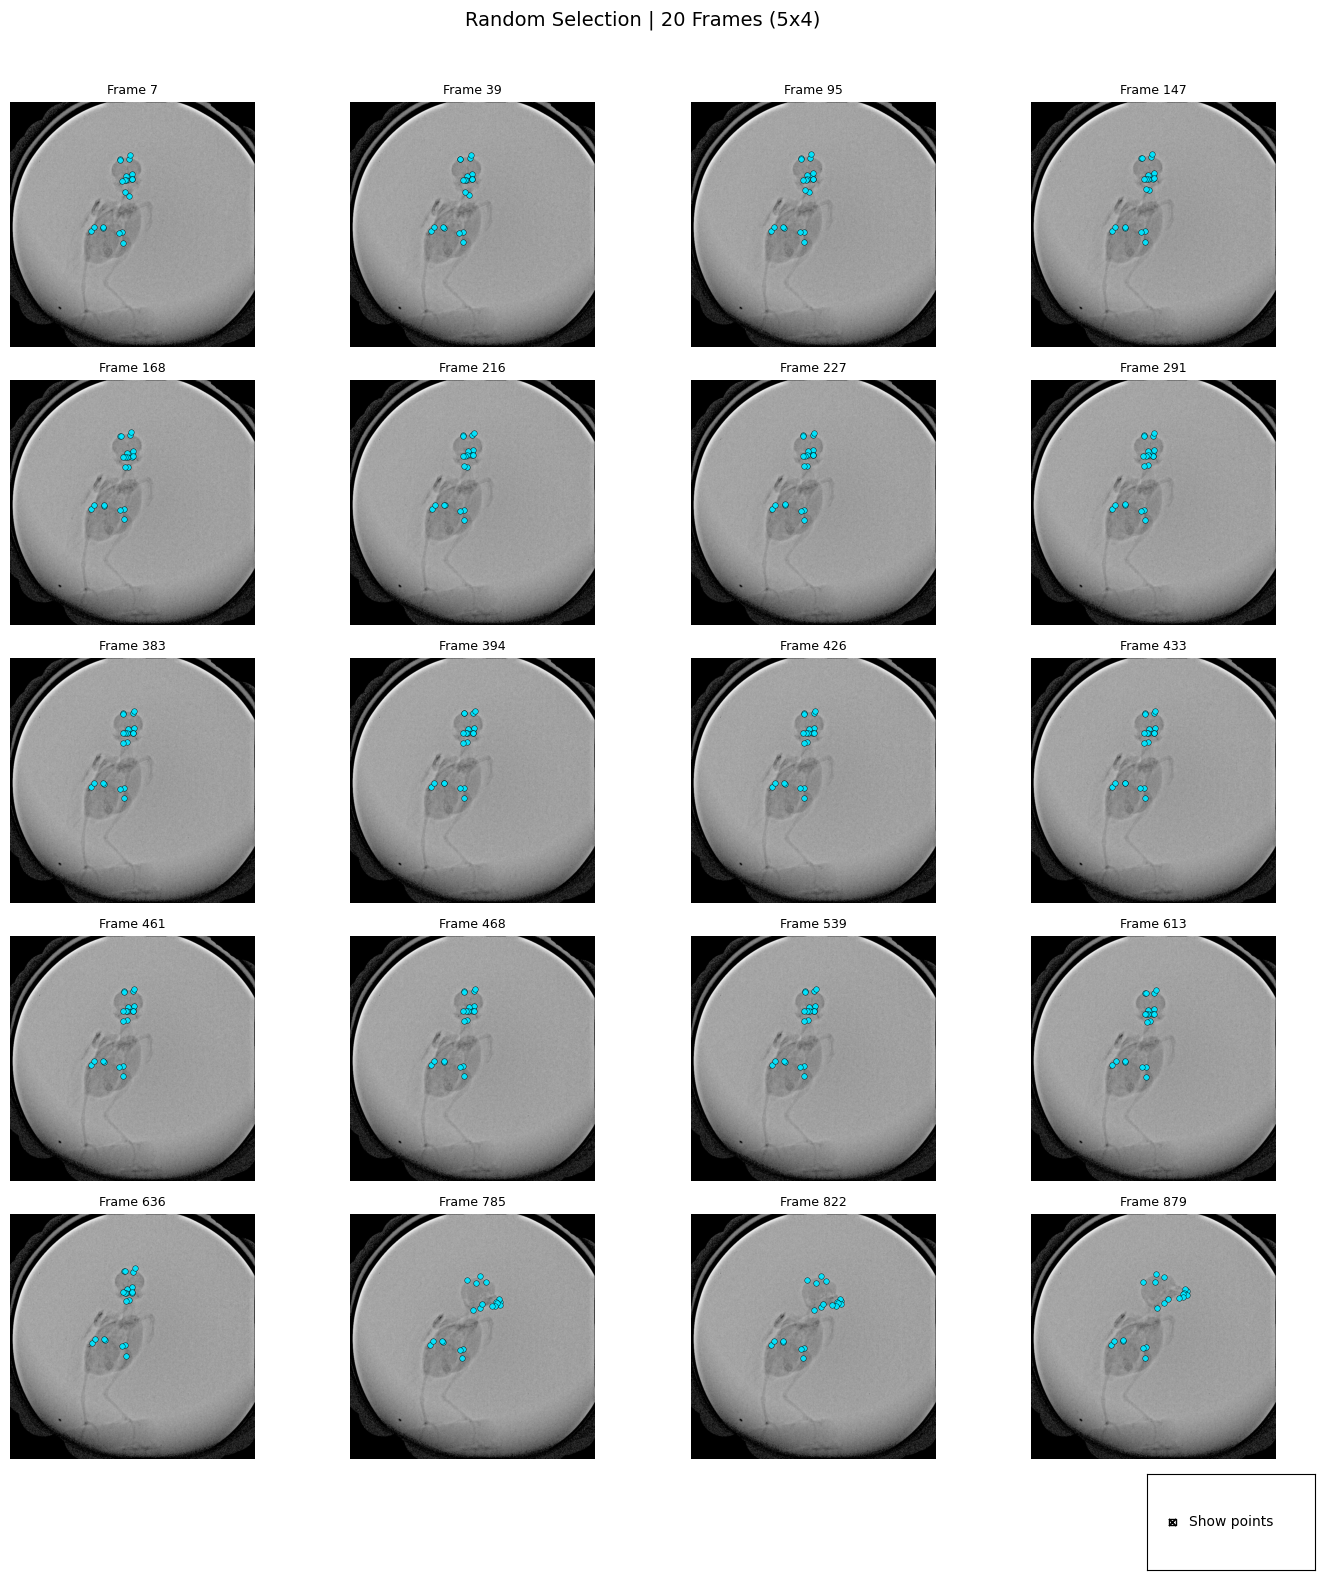

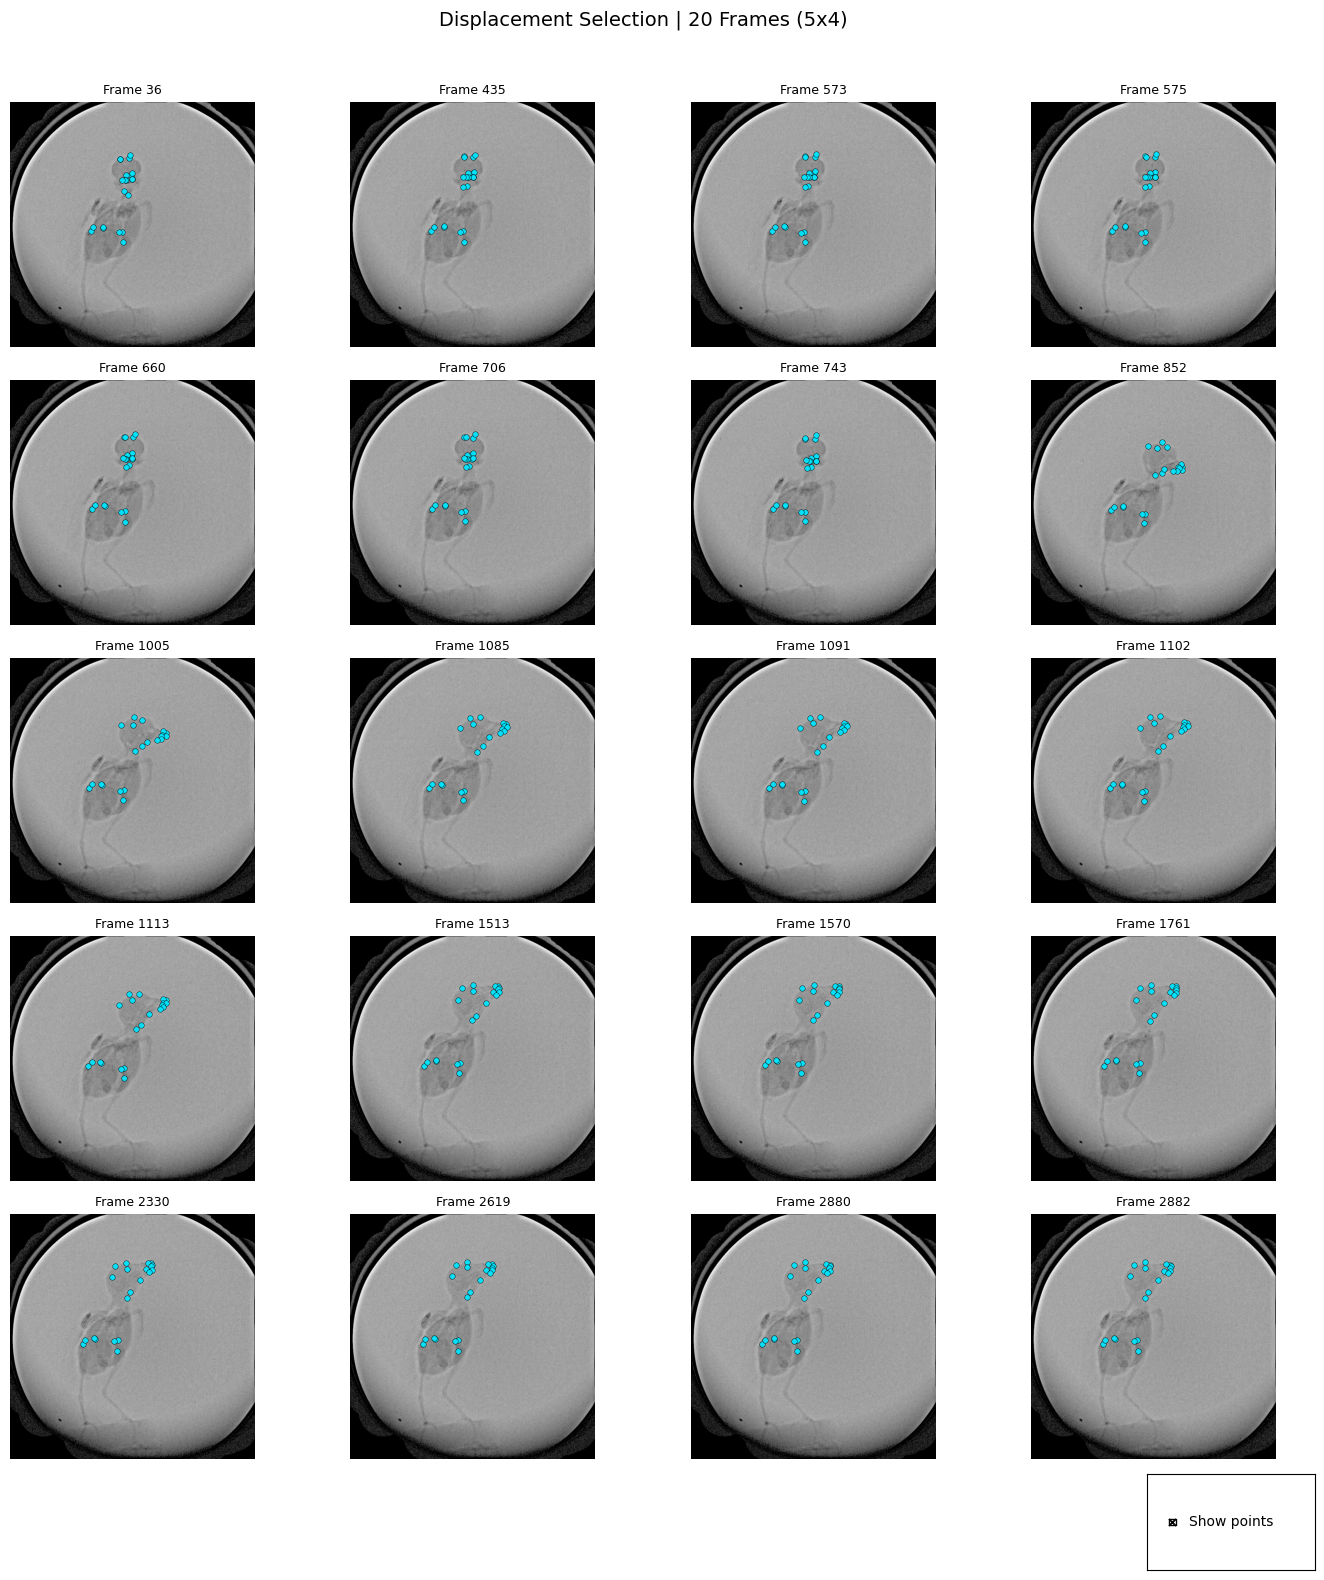

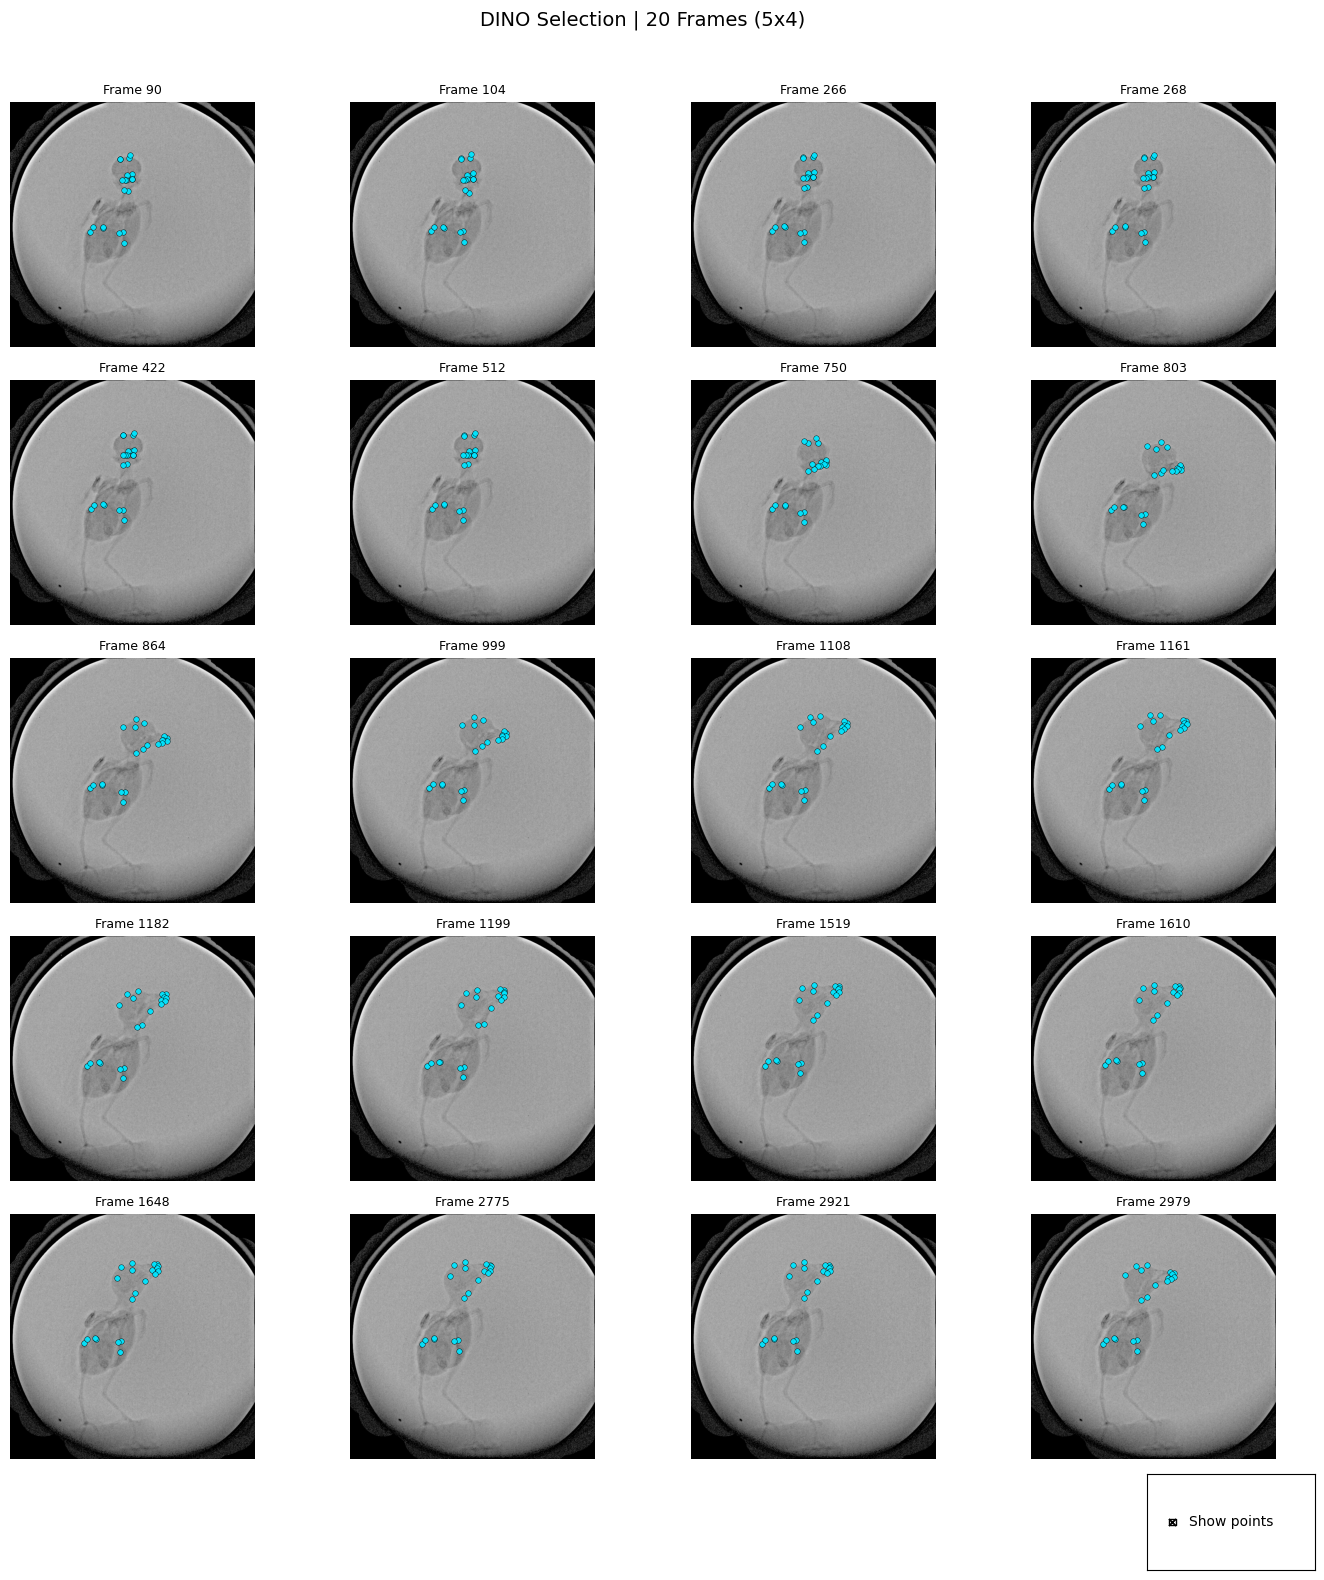

In [ ]:
# Extra Visualization
#  Visualization 2: 20-frame grids (5x4) with keypoint overlay toggle
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import CheckButtons
from PIL import Image

def _cam_xy_pairs_from_df(df, camera="cam1"):
    pat_x = re.compile(rf".+_{camera}_X$")
    pat_y = re.compile(rf".+_{camera}_Y$")
    x_cols = sorted([c for c in df.columns if pat_x.match(str(c))])
    y_cols = sorted([c for c in df.columns if pat_y.match(str(c))])

    x_map = {str(c).rsplit(f"_{camera}_", 1)[0]: c for c in x_cols}
    y_map = {str(c).rsplit(f"_{camera}_", 1)[0]: c for c in y_cols}
    keys = sorted(set(x_map).intersection(y_map))
    return [(x_map[k], y_map[k]) for k in keys]

def _top_n_frames(df, n=20):
    if df is None or len(df) == 0:
        return df
    return df.sort_index().head(int(n)).copy()

def _plot_selection_grid(df, title, camera="cam1", nrows=5, ncols=4, n_show=20, show_points=True):
    if df is None or len(df) == 0:
        print(f"{title}: no frames to plot")
        return

    view_df = _top_n_frames(df, n=n_show)
    xy_pairs = _cam_xy_pairs_from_df(view_df, camera=camera)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 16))
    axes = np.asarray(axes).reshape(-1)
    overlay_artists = []

    for ax_i, ax in enumerate(axes):
        if ax_i >= len(view_df):
            ax.axis("off")
            continue

        row = view_df.iloc[ax_i]
        frame_idx = int(view_df.index[ax_i]) + 1 if np.isfinite(pd.to_numeric(view_df.index[ax_i], errors="coerce")) else ax_i + 1
        image_path = str(row.get("image_path", ""))

        if image_path and os.path.isfile(image_path):
            try:
                with Image.open(image_path) as img:
                    ax.imshow(np.asarray(img.convert("RGB")))
            except Exception:
                ax.text(0.5, 0.5, "Image load failed", ha="center", va="center")
                ax.set_facecolor("#f3f3f3")
        else:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center")
            ax.set_facecolor("#f3f3f3")

        if xy_pairs:
            xs = []
            ys = []
            for x_col, y_col in xy_pairs:
                x = pd.to_numeric(row.get(x_col, np.nan), errors="coerce")
                y = pd.to_numeric(row.get(y_col, np.nan), errors="coerce")
                if np.isfinite(x) and np.isfinite(y):
                    xs.append(float(x))
                    ys.append(float(y))
            if xs and ys:
                scat = ax.scatter(xs, ys, s=16, c="#00e5ff", edgecolors="black", linewidths=0.3, alpha=0.95, zorder=3)
                overlay_artists.append(scat)

        ax.set_title(f"Frame {frame_idx}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"{title} | 20 Frames ({nrows}x{ncols})", fontsize=14, y=0.995)

    # Checkbox toggle for all point overlays in this figure.
    toggle_ax = fig.add_axes([0.86, 0.02, 0.12, 0.06])
    check = CheckButtons(toggle_ax, ["Show points"], [bool(show_points)])

    for artist in overlay_artists:
        artist.set_visible(bool(show_points))

    def _toggle(_label):
        visible = not overlay_artists[0].get_visible() if overlay_artists else False
        for artist in overlay_artists:
            artist.set_visible(visible)
        fig.canvas.draw_idle()

    check.on_clicked(_toggle)
    plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    plt.show()

datasets_to_plot = [
    ("Random", globals().get("random_frames_T15")),
    ("Displacement", globals().get("disp_frames_T15")),
    ("DINO", globals().get("dino_frames_T15")),
]

for method_name, method_df in datasets_to_plot:
    _plot_selection_grid(
        method_df,
        title=f"{method_name} Selection",
        camera="cam1",
        nrows=5,
        ncols=4,
        n_show=20,
        show_points=True,
    )